# TCN and Random Forest Experiments on YOLO-Pose Skeleton Windows

This notebook documents the experimental pipeline used to evaluate temporal keypoint-based models for pig behavior classification. The workflow starts from DeGCN-compatible skeleton tensors generated from YOLOv8n-Pose predictions and converts them into representations suitable for Temporal Convolutional Networks (TCN) and Random Forest classifiers.

The notebook is organized around five main goals:

1. load and validate the skeleton-window dataset originally stored in DeGCN format;
2. reshape the data from graph-based tensors into temporal feature sequences for TCN models;
3. enrich the representation with frame-to-frame velocity features;
4. train and evaluate TCN and Random Forest baselines under the same five temporal folds used for DeGCN;
5. consolidate metrics, runtime measurements, model complexity, and bootstrap comparisons against image-based baselines.

All explanatory Markdown cells were added to improve reproducibility and to make each processing step explicit. The original code cells, execution counts, and outputs were preserved so that the notebook still documents the executed experimental results.


## Load the DeGCN-compatible skeleton dataset

This cell loads the core dataset used as input for the keypoint-based experiments. The data tensor is stored in DeGCN format `(N, C, T, V, M)`, where `N` is the number of temporal windows, `C` is the number of coordinate channels, `T` is the temporal length, `V` is the number of anatomical keypoints, and `M` is the number of detected animals/person instances per sample. The labels, metadata table, and class mapping are also loaded. The printed summaries are used to verify tensor dimensions, label distribution, and consistency between arrays before any model-specific transformation is performed.


In [1]:
# %% Carregar dataset DeGCN (para uso no TCN)
import numpy as np
import pandas as pd
from pathlib import Path
import json

# =========================================================
# PATHS (ajuste se necessário)
# =========================================================
BASE = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15")

DATA_PATH   = BASE / "data_valid.npy"
LABELS_PATH = BASE / "labels_valid.npy"
META_PATH   = BASE / "meta_valid.csv"
MAP_PATH    = BASE / "labels_mix_map.json"
SPLITS_PATH = BASE / "splits_temporal_5fold_blocks"

# =========================================================
# LOAD
# =========================================================
X = np.load(DATA_PATH)          # (N, C, T, V, M)
y = np.load(LABELS_PATH)        # (N,)
meta = pd.read_csv(META_PATH)

with open(MAP_PATH, "r", encoding="utf-8") as f:
    label_map = json.load(f)

class_to_idx = label_map["class_to_idx"]
idx_to_class = {int(v): k for k, v in class_to_idx.items()}

# =========================================================
# CHECKS
# =========================================================
print("=== SHAPES ===")
print("X:", X.shape)
print("y:", y.shape)
print("meta:", meta.shape)

print("\n=== CLASSES ===")
print(idx_to_class)

print("\n=== VALORES ===")
print("min :", X.min())
print("max :", X.max())
print("mean:", X.mean())
print("std :", X.std())

print("\n=== CONSISTÊNCIA ===")
print("len(X) == len(y)?", len(X) == len(y))
print("len(X) == len(meta)?", len(X) == len(meta))

# =========================================================
# INFO EXTRA
# =========================================================
N, C, T, V, M = X.shape

print("\n=== ESTRUTURA ===")
print(f"N (amostras): {N}")
print(f"C (canais) : {C}")
print(f"T (tempo)  : {T}")
print(f"V (keypoints): {V}")
print(f"M (pessoas) : {M}")

# =========================================================
# DISTRIBUIÇÃO DE CLASSES
# =========================================================
unique, counts = np.unique(y, return_counts=True)

print("\n=== DISTRIBUIÇÃO DE CLASSES ===")
for u, c in zip(unique, counts):
    print(f"{idx_to_class[u]:15s}: {c}")

=== SHAPES ===
X: (2887, 2, 15, 9, 1)
y: (2887,)
meta: (2887, 6)

=== CLASSES ===
{0: 'walking', 1: 'running', 2: 'eating', 3: 'drinking', 4: 'lying awake', 5: 'sleeping'}

=== VALORES ===
min : 0.0
max : 1.0
mean: 0.5737311
std : 0.27917776

=== CONSISTÊNCIA ===
len(X) == len(y)? True
len(X) == len(meta)? True

=== ESTRUTURA ===
N (amostras): 2887
C (canais) : 2
T (tempo)  : 15
V (keypoints): 9
M (pessoas) : 1

=== DISTRIBUIÇÃO DE CLASSES ===
walking        : 397
running        : 310
eating         : 644
drinking       : 177
lying awake    : 583
sleeping       : 776


## Convert DeGCN tensors into TCN sequences

This cell reshapes the graph-based DeGCN tensor into a sequential format suitable for a Temporal Convolutional Network. The original tensor `(N, C, T, V, M)` is reduced by removing the singleton instance dimension `M`, transposed to place time as the second axis, and flattened across coordinates and keypoints to obtain `(N, T, F)`. In this representation, each time step is described by a fixed feature vector containing all keypoint coordinates. The transformed array is saved for reuse in later TCN experiments.


In [2]:
# %% Preparar dados para TCN: (N,C,T,V,M) -> (N,T,F)
import numpy as np
from pathlib import Path

BASE = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15")

DATA_PATH = BASE / "data_valid.npy"
OUT_PATH  = BASE / "data_valid_tcn.npy"

X = np.load(DATA_PATH)   # (N, C, T, V, M)

assert X.ndim == 5, f"Esperado 5D, veio {X.shape}"
N, C, T, V, M = X.shape
assert M == 1, f"Esperado M=1, veio M={M}"

# remove M e reorganiza para (N,T,C,V)
X2 = X[..., 0]                  # (N, C, T, V)
X2 = np.transpose(X2, (0, 2, 1, 3))   # (N, T, C, V)

# achata C e V -> F
X_tcn = X2.reshape(N, T, C * V).astype(np.float32)

np.save(OUT_PATH, X_tcn)

print("X original :", X.shape)
print("X TCN      :", X_tcn.shape)
print("Features por frame:", X_tcn.shape[-1])
print("Salvo em:", OUT_PATH)

print("\nEstatísticas:")
print("min :", X_tcn.min())
print("max :", X_tcn.max())
print("mean:", X_tcn.mean())
print("std :", X_tcn.std())

X original : (2887, 2, 15, 9, 1)
X TCN      : (2887, 15, 18)
Features por frame: 18
Salvo em: C:\Degcn-yolo\meus_dados_degcn_yolo_T15\data_valid_tcn.npy

Estatísticas:
min : 0.0
max : 1.0
mean: 0.57373106
std : 0.27917778


## Load temporal folds for TCN training

This cell loads the precomputed temporal train/validation splits. These splits are essential because consecutive frames and nearby windows are highly correlated; therefore, random splitting would overestimate performance through temporal leakage. The code checks the size of each fold, verifies that train and validation indices do not overlap, and extracts one fold as an example for subsequent training routines.


In [3]:
# %% Carregar splits temporais para treino do TCN
import numpy as np
import pandas as pd
from pathlib import Path

BASE = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15")
SPLITS = BASE / "splits_temporal_5fold_blocks"

X_tcn = np.load(BASE / "data_valid_tcn.npy")
y = np.load(BASE / "labels_valid.npy")
meta = pd.read_csv(BASE / "meta_valid.csv")

print("X_tcn:", X_tcn.shape)
print("y    :", y.shape)
print("meta :", meta.shape)

fold_info = []

for fold in range(5):
    train_idx = np.load(SPLITS / f"fold{fold}_train_idx.npy")
    val_idx   = np.load(SPLITS / f"fold{fold}_val_idx.npy")

    fold_info.append({
        "fold": fold,
        "train_samples": len(train_idx),
        "val_samples": len(val_idx),
        "intersec": len(np.intersect1d(train_idx, val_idx)),
        "max_train_idx": int(train_idx.max()),
        "max_val_idx": int(val_idx.max()),
    })

fold_df = pd.DataFrame(fold_info)
display(fold_df)

# exemplo: separar fold 0
FOLD = 0
train_idx = np.load(SPLITS / f"fold{FOLD}_train_idx.npy")
val_idx   = np.load(SPLITS / f"fold{FOLD}_val_idx.npy")

X_train, y_train = X_tcn[train_idx], y[train_idx]
X_val, y_val     = X_tcn[val_idx], y[val_idx]

print(f"\n=== Fold {FOLD} ===")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)

X_tcn: (2887, 15, 18)
y    : (2887,)
meta : (2887, 6)


,fold,train_samples,val_samples,intersec,max_train_idx,max_val_idx
0,0,2441,446,0,2886,445
1,1,2267,620,0,2886,1065
2,2,2045,842,0,2886,1907
3,3,2104,783,0,2886,2690
4,4,2691,196,0,2690,2886



=== Fold 0 ===
X_train: (2441, 15, 18)
y_train: (2441,)
X_val  : (446, 15, 18)
y_val  : (446,)


## Build PyTorch datasets, loaders, and class weights

This cell prepares one temporal fold for TCN training. It creates training and validation subsets from the transformed TCN tensor, computes class weights from the training labels to reduce the effect of class imbalance, and defines a PyTorch `Dataset` wrapper. The resulting `DataLoader` objects provide mini-batches to the neural network while preserving the same fold structure used in the DeGCN experiments.


In [4]:
# %% Dataset, DataLoader e pesos de classe para o TCN
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

BASE = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15")
SPLITS = BASE / "splits_temporal_5fold_blocks"

X_tcn = np.load(BASE / "data_valid_tcn.npy")   # (N, T, F)
y = np.load(BASE / "labels_valid.npy")         # (N,)

FOLD = 0
BATCH_SIZE = 64
NUM_WORKERS = 0

train_idx = np.load(SPLITS / f"fold{FOLD}_train_idx.npy")
val_idx   = np.load(SPLITS / f"fold{FOLD}_val_idx.npy")

X_train, y_train = X_tcn[train_idx], y[train_idx]
X_val, y_val     = X_tcn[val_idx], y[val_idx]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)

# =========================================================
# pesos de classe
# =========================================================
num_classes = len(np.unique(y))
counts = np.bincount(y_train, minlength=num_classes)
class_weights = counts.sum() / np.maximum(counts, 1)
class_weights = class_weights / class_weights.mean()

print("\nContagem por classe (train):", counts)
print("Class weights:", class_weights)

class_weights_torch = torch.tensor(class_weights, dtype=torch.float32)

# =========================================================
# dataset
# =========================================================
class TCNSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)   # (N, T, F)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TCNSequenceDataset(X_train, y_train)
val_ds   = TCNSequenceDataset(X_val, y_val)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    drop_last=False
)

# sanity check
xb, yb = next(iter(train_loader))
print("\nBatch X:", xb.shape)   # esperado: (B, T, F)
print("Batch y:", yb.shape)
print("Exemplo y:", yb[:10].tolist())

X_train: (2441, 15, 18)
y_train: (2441,)
X_val  : (446, 15, 18)
y_val  : (446,)

Contagem por classe (train): [313 308 552 170 451 647]
Class weights: [1.07100327 1.08838969 0.6072899  1.97190603 0.74329052 0.51812059]

Batch X: torch.Size([64, 15, 18])
Batch y: torch.Size([64])
Exemplo y: [2, 2, 2, 2, 4, 2, 2, 0, 2, 5]


# TCN with Position and Velocity Features


## Section: TCN with position and velocity features

This section introduces an enhanced TCN input representation that combines static keypoint positions with temporal velocity features. The goal is to provide the model with both posture information and short-term motion dynamics.


In [18]:
# %% Gerar dataset TCN com posição + velocidade de todos os keypoints
import numpy as np
from pathlib import Path

BASE = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15")

IN_PATH = BASE / "data_valid.npy"          # (N, 2, 15, 9, 1)
OUT_PATH = BASE / "data_valid_tcn_vel.npy" # (N, 15, 36)

X = np.load(IN_PATH).astype(np.float32)

print("X original:", X.shape)

N, C, T, V, M = X.shape
assert C == 2, f"Esperado C=2, veio {C}"
assert V == 9, f"Esperado V=9, veio {V}"
assert M == 1, f"Esperado M=1, veio {M}"

# remove M -> (N, 2, T, 9)
X2 = X[..., 0]

# reorganiza para (N, T, 2, 9)
X2 = np.transpose(X2, (0, 2, 1, 3))

# posição: (N, T, 18)
X_pos = X2.reshape(N, T, C * V)

# velocidade: diferença temporal frame a frame
X_vel = np.zeros_like(X2, dtype=np.float32)
X_vel[:, 1:, :, :] = X2[:, 1:, :, :] - X2[:, :-1, :, :]
# frame 0 fica zerado

# velocidade -> (N, T, 18)
X_vel = X_vel.reshape(N, T, C * V)

# concatena posição + velocidade -> (N, T, 36)
X_out = np.concatenate([X_pos, X_vel], axis=2).astype(np.float32)

np.save(OUT_PATH, X_out)

print("X posição:", X_pos.shape)
print("X velocidade:", X_vel.shape)
print("X final:", X_out.shape)
print("Features por frame:", X_out.shape[-1])
print("Salvo em:", OUT_PATH)

print("\nEstatísticas:")
print("min :", X_out.min())
print("max :", X_out.max())
print("mean:", X_out.mean())
print("std :", X_out.std())

print("\nVelocidade:")
print("min vel :", X_vel.min())
print("max vel :", X_vel.max())
print("mean vel:", X_vel.mean())
print("std vel :", X_vel.std())

X original: (2887, 2, 15, 9, 1)
X posição: (2887, 15, 18)
X velocidade: (2887, 15, 18)
X final: (2887, 15, 36)
Features por frame: 36
Salvo em: C:\Degcn-yolo\meus_dados_degcn_yolo_T15\data_valid_tcn_vel.npy

Estatísticas:
min : -0.41252083
max : 1.0
mean: 0.28677982
std : 0.34859496

Velocidade:
min vel : -0.41252083
max vel : 0.50941664
mean vel: -0.00017147943
std vel : 0.020362088


## Create TCN input with keypoint positions and velocities

This cell constructs a richer temporal representation for the TCN. First, the original skeleton coordinates are reshaped into per-frame position vectors. Then, frame-to-frame velocity is computed as the difference between consecutive keypoint coordinates. The first frame receives zero velocity because there is no previous frame. Finally, position and velocity vectors are concatenated, doubling the feature dimension and allowing the TCN to learn both spatial configuration and motion dynamics.


In [11]:
# %% Medir tempo de inferência consolidado nos 5 folds
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# =========================================================
# PATHS
# =========================================================
BASE = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15")
SAVE_DIR = Path(r"C:\Degcn-yolo\Doutorado\experimentos\tcn_5fold_same_splits_as_degcn")
SPLITS = BASE / "splits_temporal_5fold_blocks"
X_PATH = BASE / "data_valid_tcn.npy"
Y_PATH = BASE / "labels_valid.npy"
MAP_PATH = BASE / "labels_mix_map.json"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

X_all = np.load(X_PATH).astype(np.float32)
y_all = np.load(Y_PATH).astype(np.int64)

with open(MAP_PATH, "r", encoding="utf-8") as f:
    label_map = json.load(f)

class_to_idx = label_map["class_to_idx"]
idx_to_class = {int(v): k for k, v in class_to_idx.items()}
num_classes = len(idx_to_class)

# =========================================================
# DATASET
# =========================================================
class TCNSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# =========================================================
# MODEL
# =========================================================
class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.residual = nn.Identity()
        if in_channels != out_channels:
            self.residual = nn.Conv1d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        res = self.residual(x)
        out = self.drop1(self.relu1(self.bn1(self.conv1(x))))
        out = self.drop2(self.relu2(self.bn2(self.conv2(out))))
        return out + res

class TCNClassifier(nn.Module):
    def __init__(self, input_dim=18, num_classes=6, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.block1 = TemporalBlock(input_dim, hidden_dim, kernel_size=3, dilation=1, dropout=dropout)
        self.block2 = TemporalBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=2, dropout=dropout)
        self.block3 = TemporalBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=4, dropout=dropout)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x).squeeze(-1)
        x = self.fc(x)
        return x

# =========================================================
# LOOP FOLDS
# =========================================================
rows = []
total_samples = 0
total_time = 0.0

for fold in range(5):
    fold_dir = SAVE_DIR / f"fold{fold}"
    ckpt_path = fold_dir / "tcn_best.pt"
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Checkpoint não encontrado: {ckpt_path}")

    ckpt = torch.load(ckpt_path, map_location=device)

    model = TCNClassifier(
        input_dim=int(ckpt["input_dim"]),
        num_classes=int(ckpt["num_classes"]),
        hidden_dim=int(ckpt["hidden_dim"]),
        dropout=float(ckpt["dropout"]),
    ).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    val_idx = np.load(SPLITS / f"fold{fold}_val_idx.npy")
    X_val, y_val = X_all[val_idx], y_all[val_idx]

    val_ds = TCNSequenceDataset(X_val, y_val)
    val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=0)

    # warmup
    with torch.no_grad():
        xb, _ = next(iter(val_loader))
        xb = xb.to(device)
        _ = model(xb)

    if device == "cuda":
        torch.cuda.synchronize()

    t0 = time.perf_counter()

    preds = []
    trues = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            preds.extend(pred.tolist())
            trues.extend(yb.numpy().tolist())

    if device == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - t0

    rows.append({
        "fold": fold,
        "n_samples": len(val_ds),
        "time_seconds": elapsed,
        "time_ms_per_sample": 1000.0 * elapsed / len(val_ds),
    })

    total_samples += len(val_ds)
    total_time += elapsed

time_df = pd.DataFrame(rows)
time_df.to_csv(SAVE_DIR / "inference_time_5fold.csv", index=False)

print("=" * 70)
print("TEMPO DE INFERÊNCIA")
print("=" * 70)
print(time_df)

print("\nConsolidado:")
print(f"Total samples          : {total_samples}")
print(f"Total time (s)         : {total_time:.4f}")
print(f"Mean time / sample (ms): {1000.0 * total_time / total_samples:.4f}")
print(f"Mean time / fold (s)   : {time_df['time_seconds'].mean():.4f}")

device: cuda


C:\Users\franc\AppData\Local\Temp\ipykernel_9288\1705375233.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


TEMPO DE INFERÊNCIA
   fold  n_samples  time_seconds  time_ms_per_sample
0     0        446      0.043707            0.097997
1     1        620      0.051959            0.083805
2     2        842      0.061073            0.072533
3     3        783      0.059455            0.075932
4     4        196      0.012630            0.064439

Consolidado:
Total samples          : 2887
Total time (s)         : 0.2288
Mean time / sample (ms): 0.0793
Mean time / fold (s)   : 0.0458


## Benchmark consolidated TCN inference time across five folds

This cell measures inference time for the trained TCN models across the five temporal folds. It reloads the dataset, labels, class mapping, and trained fold-specific models, then performs repeated forward passes to estimate average prediction time. This runtime benchmark is important for comparing the practical deployment cost of TCN against DeGCN, Random Forest, SlowFast, and ViTAM-SlowFast baselines.


In [19]:
# %% TCN 5-fold temporal CV com posição + velocidade******************************Melhor TCN 6 classes*************
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# =========================================================
# PATHS
# =========================================================
BASE = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15")
X_PATH = BASE / "data_valid_tcn_vel.npy"
Y_PATH = BASE / "labels_valid.npy"
MAP_PATH = BASE / "labels_mix_map.json"
SPLITS = BASE / "splits_temporal_5fold_blocks"

SAVE_DIR = Path(r"C:\Degcn-yolo\Doutorado\experimentos\tcn_vel_5fold_same_splits_as_degcn")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# HYPERPARAMS
# =========================================================
EPOCHS = 60
BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0
HIDDEN_DIM = 64
DROPOUT = 0.2
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# =========================================================
# LOAD DATA
# =========================================================
X_all = np.load(X_PATH).astype(np.float32)   # (N, T, F)
y_all = np.load(Y_PATH).astype(np.int64)

with open(MAP_PATH, "r", encoding="utf-8") as f:
    label_map = json.load(f)

class_to_idx = label_map["class_to_idx"]
idx_to_class = {int(v): k for k, v in class_to_idx.items()}
num_classes = len(idx_to_class)
input_dim = X_all.shape[-1]

print("X_all:", X_all.shape)
print("y_all:", y_all.shape)
print("Classes:", idx_to_class)

# =========================================================
# DATASET
# =========================================================
class TCNSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# =========================================================
# MODEL
# =========================================================
class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2

        self.conv1 = nn.Conv1d(
            in_channels, out_channels,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation
        )
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            out_channels, out_channels,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation
        )
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.residual = nn.Identity()
        if in_channels != out_channels:
            self.residual = nn.Conv1d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        res = self.residual(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.drop1(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = self.drop2(out)

        return out + res

class TCNClassifier(nn.Module):
    def __init__(self, input_dim=36, num_classes=6, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.block1 = TemporalBlock(input_dim, hidden_dim, kernel_size=3, dilation=1, dropout=dropout)
        self.block2 = TemporalBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=2, dropout=dropout)
        self.block3 = TemporalBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=4, dropout=dropout)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (B, T, F)
        x = x.transpose(1, 2)   # -> (B, F, T)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x).squeeze(-1)
        x = self.fc(x)
        return x

# =========================================================
# HELPERS
# =========================================================
def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)

    losses = []
    y_true = []
    y_pred = []

    with torch.set_grad_enabled(train_mode):
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            losses.append(loss.item())

            pred = torch.argmax(logits, dim=1).detach().cpu().numpy()
            yt = yb.detach().cpu().numpy()

            y_true.extend(yt.tolist())
            y_pred.extend(pred.tolist())

    avg_loss = float(np.mean(losses))
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    return avg_loss, acc, macro_f1, np.array(y_true), np.array(y_pred)

# =========================================================
# CV LOOP
# =========================================================
fold_rows = []

for fold in range(5):
    print("\n" + "=" * 70)
    print(f"FOLD {fold}")
    print("=" * 70)

    train_idx = np.load(SPLITS / f"fold{fold}_train_idx.npy")
    val_idx   = np.load(SPLITS / f"fold{fold}_val_idx.npy")

    X_train, y_train = X_all[train_idx], y_all[train_idx]
    X_val, y_val     = X_all[val_idx], y_all[val_idx]

    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
    print("Interseção:", len(np.intersect1d(train_idx, val_idx)))

    counts = np.bincount(y_train, minlength=num_classes)
    class_weights = counts.sum() / np.maximum(counts, 1)
    class_weights = class_weights / class_weights.mean()
    class_weights_torch = torch.tensor(class_weights, dtype=torch.float32).to(device)

    print("Class counts:", counts)
    print("Class weights:", np.round(class_weights, 4))

    train_ds = TCNSequenceDataset(X_train, y_train)
    val_ds   = TCNSequenceDataset(X_val, y_val)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=False)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=False)

    model = TCNClassifier(
        input_dim=input_dim,
        num_classes=num_classes,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights_torch)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=5
    )

    best_val_f1 = -1.0
    best_epoch = -1
    best_state = None
    best_val_true = None
    best_val_pred = None

    history_rows = []

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc, train_f1, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1, val_true, val_pred = run_epoch(model, val_loader, criterion, optimizer=None)

        scheduler.step(val_f1)

        history_rows.append({
            "fold": fold,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "train_f1": train_f1,
            "val_f1": val_f1,
            "lr": optimizer.param_groups[0]["lr"],
        })

        print(
            f"Epoch {epoch:03d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | "
            f"train_f1={train_f1:.4f} | val_f1={val_f1:.4f}"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_state = {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "best_val_f1": best_val_f1,
                "fold": fold,
                "input_dim": input_dim,
                "num_classes": num_classes,
                "hidden_dim": HIDDEN_DIM,
                "dropout": DROPOUT,
                "class_weights": class_weights.tolist(),
            }
            best_val_true = val_true.copy()
            best_val_pred = val_pred.copy()

    fold_dir = SAVE_DIR / f"fold{fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    torch.save(best_state, fold_dir / "tcn_best.pt")

    hist_df = pd.DataFrame(history_rows)
    hist_df.to_csv(fold_dir / "history.csv", index=False)

    report = classification_report(
        best_val_true,
        best_val_pred,
        labels=list(range(num_classes)),
        target_names=[idx_to_class[i] for i in range(num_classes)],
        digits=4,
        zero_division=0,
        output_dict=True
    )
    pd.DataFrame(report).transpose().to_csv(fold_dir / "classification_report.csv")

    cm = confusion_matrix(best_val_true, best_val_pred, labels=list(range(num_classes)))
    np.save(fold_dir / "confusion_matrix.npy", cm)

    fold_row = {
        "fold": fold,
        "best_epoch": best_epoch,
        "best_val_f1": best_val_f1,
        "best_val_acc": accuracy_score(best_val_true, best_val_pred),
    }
    fold_rows.append(fold_row)

    print("\nMelhor resultado do fold:")
    print(fold_row)

summary_df = pd.DataFrame(fold_rows)
summary_df.to_csv(SAVE_DIR / "summary_5fold.csv", index=False)

print("\n" + "=" * 70)
print("RESUMO 5-FOLD")
print("=" * 70)
print(summary_df)

print("\nMédia ± DP")
print(f"Accuracy : {summary_df['best_val_acc'].mean():.4f} ± {summary_df['best_val_acc'].std(ddof=1):.4f}")
print(f"Macro-F1 : {summary_df['best_val_f1'].mean():.4f} ± {summary_df['best_val_f1'].std(ddof=1):.4f}")

print("\nArtefatos salvos em:")
print(SAVE_DIR)

device: cuda
X_all: (2887, 15, 36)
y_all: (2887,)
Classes: {0: 'walking', 1: 'running', 2: 'eating', 3: 'drinking', 4: 'lying awake', 5: 'sleeping'}

FOLD 0
X_train: (2441, 15, 36) y_train: (2441,)
X_val  : (446, 15, 36) y_val  : (446,)
Interseção: 0
Class counts: [313 308 552 170 451 647]
Class weights: [1.071  1.0884 0.6073 1.9719 0.7433 0.5181]
Epoch 001/60 | train_loss=1.2724 | val_loss=1.3264 | train_acc=0.4764 | val_acc=0.3722 | train_f1=0.4319 | val_f1=0.3234
Epoch 002/60 | train_loss=0.9190 | val_loss=2.0117 | train_acc=0.5838 | val_acc=0.3744 | train_f1=0.5488 | val_f1=0.3750
Epoch 003/60 | train_loss=0.8331 | val_loss=1.1167 | train_acc=0.6276 | val_acc=0.5269 | train_f1=0.6096 | val_f1=0.4498
Epoch 004/60 | train_loss=0.7930 | val_loss=1.7577 | train_acc=0.6485 | val_acc=0.4215 | train_f1=0.6227 | val_f1=0.3686
Epoch 005/60 | train_loss=0.7792 | val_loss=1.1734 | train_acc=0.6489 | val_acc=0.5135 | train_f1=0.6294 | val_f1=0.4218
Epoch 006/60 | train_loss=0.7581 | val_loss=1

## Train the six-class TCN with position and velocity features

This cell runs the main five-fold temporal cross-validation experiment for the KP-TCN/TCN model in the six-class scenario. It defines the temporal convolutional architecture, trains one model per fold, evaluates validation performance, saves predictions and confusion matrices, and stores fold-specific metrics. The same temporal splits used by DeGCN are reused here so that performance comparisons are methodologically aligned.


RESULTADO FINAL — TCN COM VELOCIDADE
Acurácia        : 0.725667
Macro Precision : 0.715584
Macro Recall    : 0.732677
Macro F1        : 0.722474
Weighted F1     : 0.724488
N amostras      : 2887

Resumo por fold:


,fold,best_epoch,best_val_acc,best_val_f1
0,0,50,0.650224,0.625373
1,1,59,0.830645,0.746176
2,2,38,0.751781,0.640305
3,3,55,0.701149,0.688555
4,4,5,0.551020,0.268016



Relatório consolidado por classe:


,precision,recall,f1-score,support
walking,0.683908,0.599496,0.638926,397.000000
running,0.625000,0.693548,0.657492,310.000000
eating,0.964396,0.967391,0.965891,644.000000
drinking,0.754808,0.887006,0.815584,177.000000
lying awake,0.561739,0.554031,0.557858,583.000000
sleeping,0.703655,0.694588,0.699092,776.000000
accuracy,0.725667,0.725667,0.725667,0.725667
macro avg,0.715584,0.732677,0.722474,2887.000000
weighted avg,0.725135,0.725667,0.724488,2887.000000



Matriz de confusão consolidada:


,walking,running,eating,drinking,lying awake,sleeping
walking,238,112,4,13,18,12
running,79,215,12,1,1,2
eating,1,10,623,1,4,5
drinking,7,0,0,157,9,4
lying awake,19,7,4,26,323,204
sleeping,4,0,3,10,220,539


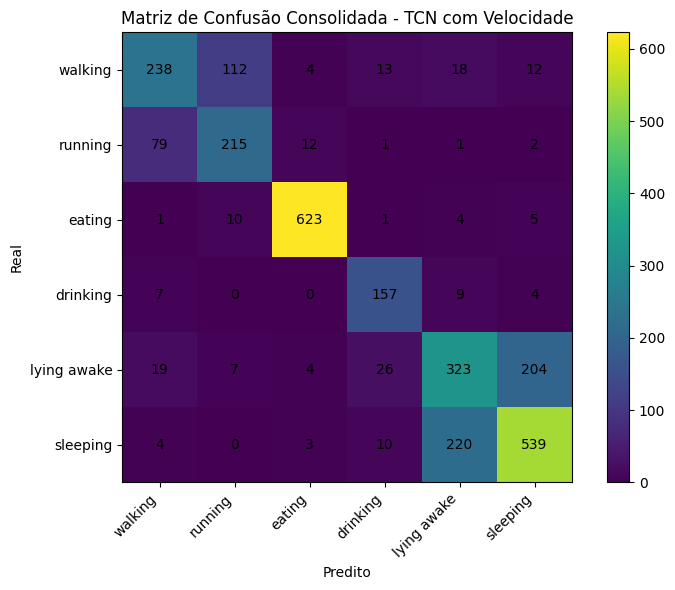


Arquivos salvos em:
C:\Degcn-yolo\Doutorado\experimentos\tcn_vel_5fold_same_splits_as_degcn


In [20]:
# %% Consolidação final - TCN com posição + velocidade
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# =========================================================
# PATHS
# =========================================================
SAVE_DIR = Path(r"C:\Degcn-yolo\Doutorado\experimentos\tcn_vel_5fold_same_splits_as_degcn")
BASE = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15")
MAP_PATH = BASE / "labels_mix_map.json"

with open(MAP_PATH, "r", encoding="utf-8") as f:
    label_map = json.load(f)

class_to_idx = label_map["class_to_idx"]
idx_to_class = {int(v): k for k, v in class_to_idx.items()}
num_classes = len(idx_to_class)
class_names = [idx_to_class[i] for i in range(num_classes)]

# =========================================================
# SOMAR MATRIZES DOS 5 FOLDS
# =========================================================
cm_total = np.zeros((num_classes, num_classes), dtype=np.int64)
fold_summary = []

for fold in range(5):
    fold_dir = SAVE_DIR / f"fold{fold}"
    cm_path = fold_dir / "confusion_matrix.npy"
    hist_path = fold_dir / "history.csv"

    if not cm_path.exists():
        raise FileNotFoundError(f"Não encontrei: {cm_path}")

    cm = np.load(cm_path)
    cm_total += cm

    row = {"fold": fold}
    if hist_path.exists():
        hist = pd.read_csv(hist_path)
        best_idx = hist["val_f1"].idxmax()
        row["best_epoch"] = int(hist.loc[best_idx, "epoch"])
        row["best_val_acc"] = float(hist.loc[best_idx, "val_acc"])
        row["best_val_f1"] = float(hist.loc[best_idx, "val_f1"])
    fold_summary.append(row)

fold_summary_df = pd.DataFrame(fold_summary)

# =========================================================
# RECONSTRUIR y_true / y_pred A PARTIR DA MATRIZ
# =========================================================
all_true = []
all_pred = []

for i in range(num_classes):
    for j in range(num_classes):
        n = cm_total[i, j]
        if n > 0:
            all_true.extend([i] * n)
            all_pred.extend([j] * n)

all_true = np.array(all_true, dtype=np.int64)
all_pred = np.array(all_pred, dtype=np.int64)

# =========================================================
# MÉTRICAS GLOBAIS
# =========================================================
acc = accuracy_score(all_true, all_pred)
macro_precision = precision_score(
    all_true, all_pred,
    average="macro",
    labels=list(range(num_classes)),
    zero_division=0
)
macro_recall = recall_score(
    all_true, all_pred,
    average="macro",
    labels=list(range(num_classes)),
    zero_division=0
)
macro_f1 = f1_score(
    all_true, all_pred,
    average="macro",
    labels=list(range(num_classes)),
    zero_division=0
)
weighted_f1 = f1_score(
    all_true, all_pred,
    average="weighted",
    labels=list(range(num_classes)),
    zero_division=0
)

report = classification_report(
    all_true,
    all_pred,
    labels=list(range(num_classes)),
    target_names=class_names,
    digits=4,
    zero_division=0,
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()

# =========================================================
# SALVAR
# =========================================================
np.save(SAVE_DIR / "confusion_matrix_consolidated.npy", cm_total)
fold_summary_df.to_csv(SAVE_DIR / "summary_5fold_rebuilt.csv", index=False)
report_df.to_csv(SAVE_DIR / "classification_report_consolidated.csv")

metrics_df = pd.DataFrame([{
    "accuracy": acc,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
    "n_samples_total": len(all_true),
}])
metrics_df.to_csv(SAVE_DIR / "metrics_consolidated.csv", index=False)

# =========================================================
# EXIBIR RESULTADOS
# =========================================================
print("=" * 80)
print("RESULTADO FINAL — TCN COM VELOCIDADE")
print("=" * 80)
print(f"Acurácia        : {acc:.6f}")
print(f"Macro Precision : {macro_precision:.6f}")
print(f"Macro Recall    : {macro_recall:.6f}")
print(f"Macro F1        : {macro_f1:.6f}")
print(f"Weighted F1     : {weighted_f1:.6f}")
print(f"N amostras      : {len(all_true)}")

print("\nResumo por fold:")
display(fold_summary_df)

print("\nRelatório consolidado por classe:")
display(report_df)

print("\nMatriz de confusão consolidada:")
cm_df = pd.DataFrame(cm_total, index=class_names, columns=class_names)
display(cm_df)

# =========================================================
# PLOT DA MATRIZ
# =========================================================
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_total)

ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predito")
ax.set_ylabel("Real")
ax.set_title("Matriz de Confusão Consolidada - TCN com Velocidade")

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, str(cm_total[i, j]), ha="center", va="center")

plt.colorbar(im)
plt.tight_layout()
plt.show()

print("\nArquivos salvos em:")
print(SAVE_DIR)

# TCN with Position and Velocity Features — Four-Class Scenario


## Consolidate six-class TCN results

This cell aggregates the five fold-level outputs from the six-class TCN experiment. It sums the confusion matrices, concatenates predictions, and computes consolidated metrics such as accuracy, macro precision, macro recall, macro F1-score, and class-wise reports. This step produces publication-ready performance summaries and figures for the six-class TCN model.


In [24]:
# %% Gerar versão 4 classes para TCN (posição + velocidade) com classes agrupadas
import json
from pathlib import Path

import numpy as np
import pandas as pd

# =========================================================
# PATHS
# =========================================================
BASE_IN = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15")
BASE_OUT = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes")
BASE_OUT.mkdir(parents=True, exist_ok=True)

X_PATH = BASE_IN / "data_valid_tcn_vel.npy"
Y_PATH = BASE_IN / "labels_valid.npy"
META_PATH = BASE_IN / "meta_valid.csv"
MAP_PATH = BASE_IN / "labels_mix_map.json"
SPLITS_IN = BASE_IN / "splits_temporal_5fold_blocks"
SPLITS_OUT = BASE_OUT / "splits_temporal_5fold_blocks"
SPLITS_OUT.mkdir(parents=True, exist_ok=True)

# =========================================================
# LOAD
# =========================================================
X = np.load(X_PATH).astype(np.float32)
y = np.load(Y_PATH).astype(np.int64)
meta = pd.read_csv(META_PATH)

with open(MAP_PATH, "r", encoding="utf-8") as f:
    mp = json.load(f)

class_to_idx_old = mp["class_to_idx"]
idx_to_class_old = {int(v): k for k, v in class_to_idx_old.items()}

print("Classes originais:", idx_to_class_old)

# =========================================================
# NOVO MAPEAMENTO 4 CLASSES
# =========================================================
# originais:
# 0 walking
# 1 running
# 2 eating
# 3 drinking
# 4 lying awake
# 5 sleeping

merged_mapping = {
    0: 0,  # walking  -> deslocando
    1: 0,  # running  -> deslocando
    2: 1,  # eating   -> comendo
    3: 2,  # drinking -> bebendo
    4: 3,  # lying awake -> deitado
    5: 3,  # sleeping    -> deitado
}

new_class_names = {
    0: "deslocando",
    1: "comendo",
    2: "bebendo",
    3: "deitado",
}

class_to_idx_new = {v: k for k, v in new_class_names.items()}

# =========================================================
# RECRIAR RÓTULOS
# =========================================================
y_new = np.array([merged_mapping[int(lbl)] for lbl in y], dtype=np.int64)

print("\nShapes:")
print("X:", X.shape)
print("y antigo:", y.shape)
print("y novo  :", y_new.shape)
print("meta:", meta.shape)

# =========================================================
# SALVAR DADOS
# =========================================================
np.save(BASE_OUT / "data_valid_tcn_vel_4c.npy", X)
np.save(BASE_OUT / "labels_valid_4c.npy", y_new)
meta.to_csv(BASE_OUT / "meta_valid_4c.csv", index=False)

with open(BASE_OUT / "labels_map_4c.json", "w", encoding="utf-8") as f:
    json.dump({"class_to_idx": class_to_idx_new}, f, ensure_ascii=False, indent=2)

print("\nArquivos salvos em:", BASE_OUT)

# =========================================================
# RECRIAR SPLITS (iguais aos antigos, porque não removemos amostras)
# =========================================================
for fold in range(5):
    train_idx = np.load(SPLITS_IN / f"fold{fold}_train_idx.npy")
    val_idx   = np.load(SPLITS_IN / f"fold{fold}_val_idx.npy")

    np.save(SPLITS_OUT / f"fold{fold}_train_idx.npy", train_idx)
    np.save(SPLITS_OUT / f"fold{fold}_val_idx.npy", val_idx)

    print(f"\nFold {fold}")
    print("train:", len(train_idx))
    print("val  :", len(val_idx))
    print("interseção:", len(np.intersect1d(train_idx, val_idx)))

print("\nNovo mapeamento 4 classes:")
print(class_to_idx_new)

print("\nDistribuição final:")
unique, counts = np.unique(y_new, return_counts=True)
for u, c in zip(unique, counts):
    print(f"{new_class_names[u]:15s}: {c}")

Classes originais: {0: 'walking', 1: 'running', 2: 'eating', 3: 'drinking', 4: 'lying awake', 5: 'sleeping'}

Shapes:
X: (2887, 15, 36)
y antigo: (2887,)
y novo  : (2887,)
meta: (2887, 6)

Arquivos salvos em: C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes

Fold 0
train: 2441
val  : 446
interseção: 0

Fold 1
train: 2267
val  : 620
interseção: 0

Fold 2
train: 2045
val  : 842
interseção: 0

Fold 3
train: 2104
val  : 783
interseção: 0

Fold 4
train: 2691
val  : 196
interseção: 0

Novo mapeamento 4 classes:
{'deslocando': 0, 'comendo': 1, 'bebendo': 2, 'deitado': 3}

Distribuição final:
deslocando     : 707
comendo        : 644
bebendo        : 177
deitado        : 1359


## Section: Four-class TCN setting

This section switches from the original six behavioral classes to the aggregated four-class formulation. The grouping reduces ambiguity between closely related behaviors and allows direct comparison with other experimental settings.


In [25]:
# %% TCN 5-fold temporal CV com posição + velocidade (4 classes agrupadas)*******************************
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# =========================================================
# PATHS
# =========================================================
BASE = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes")
X_PATH = BASE / "data_valid_tcn_vel_4c.npy"
Y_PATH = BASE / "labels_valid_4c.npy"
MAP_PATH = BASE / "labels_map_4c.json"
SPLITS = BASE / "splits_temporal_5fold_blocks"

SAVE_DIR = Path(r"C:\Degcn-yolo\Doutorado\experimentos\tcn_vel_4classes_5fold_same_splits_as_degcn")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# HYPERPARAMS
# =========================================================
EPOCHS = 60
BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0
HIDDEN_DIM = 64
DROPOUT = 0.2
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# =========================================================
# LOAD DATA
# =========================================================
X_all = np.load(X_PATH).astype(np.float32)   # (N, T, F)
y_all = np.load(Y_PATH).astype(np.int64)

with open(MAP_PATH, "r", encoding="utf-8") as f:
    label_map = json.load(f)

class_to_idx = label_map["class_to_idx"]
idx_to_class = {int(v): k for k, v in class_to_idx.items()}
num_classes = len(idx_to_class)
input_dim = X_all.shape[-1]

print("X_all:", X_all.shape)
print("y_all:", y_all.shape)
print("Classes:", idx_to_class)

# =========================================================
# DATASET
# =========================================================
class TCNSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# =========================================================
# MODEL
# =========================================================
class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2

        self.conv1 = nn.Conv1d(
            in_channels, out_channels,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation
        )
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            out_channels, out_channels,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation
        )
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.residual = nn.Identity()
        if in_channels != out_channels:
            self.residual = nn.Conv1d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        res = self.residual(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.drop1(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = self.drop2(out)

        return out + res

class TCNClassifier(nn.Module):
    def __init__(self, input_dim=36, num_classes=4, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.block1 = TemporalBlock(input_dim, hidden_dim, kernel_size=3, dilation=1, dropout=dropout)
        self.block2 = TemporalBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=2, dropout=dropout)
        self.block3 = TemporalBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=4, dropout=dropout)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (B, T, F)
        x = x.transpose(1, 2)   # -> (B, F, T)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x).squeeze(-1)
        x = self.fc(x)
        return x

# =========================================================
# HELPERS
# =========================================================
def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)

    losses = []
    y_true = []
    y_pred = []

    with torch.set_grad_enabled(train_mode):
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            losses.append(loss.item())

            pred = torch.argmax(logits, dim=1).detach().cpu().numpy()
            yt = yb.detach().cpu().numpy()

            y_true.extend(yt.tolist())
            y_pred.extend(pred.tolist())

    avg_loss = float(np.mean(losses))
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    return avg_loss, acc, macro_f1, np.array(y_true), np.array(y_pred)

# =========================================================
# CV LOOP
# =========================================================
fold_rows = []

for fold in range(5):
    print("\n" + "=" * 70)
    print(f"FOLD {fold}")
    print("=" * 70)

    train_idx = np.load(SPLITS / f"fold{fold}_train_idx.npy")
    val_idx   = np.load(SPLITS / f"fold{fold}_val_idx.npy")

    X_train, y_train = X_all[train_idx], y_all[train_idx]
    X_val, y_val     = X_all[val_idx], y_all[val_idx]

    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
    print("Interseção:", len(np.intersect1d(train_idx, val_idx)))

    counts = np.bincount(y_train, minlength=num_classes)
    class_weights = counts.sum() / np.maximum(counts, 1)
    class_weights = class_weights / class_weights.mean()
    class_weights_torch = torch.tensor(class_weights, dtype=torch.float32).to(device)

    print("Class counts:", counts)
    print("Class weights:", np.round(class_weights, 4))

    train_ds = TCNSequenceDataset(X_train, y_train)
    val_ds   = TCNSequenceDataset(X_val, y_val)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        drop_last=False
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        drop_last=False
    )

    model = TCNClassifier(
        input_dim=input_dim,
        num_classes=num_classes,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights_torch)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=5
    )

    best_val_f1 = -1.0
    best_epoch = -1
    best_state = None
    best_val_true = None
    best_val_pred = None

    history_rows = []

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc, train_f1, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1, val_true, val_pred = run_epoch(model, val_loader, criterion, optimizer=None)

        scheduler.step(val_f1)

        history_rows.append({
            "fold": fold,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "train_f1": train_f1,
            "val_f1": val_f1,
            "lr": optimizer.param_groups[0]["lr"],
        })

        print(
            f"Epoch {epoch:03d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | "
            f"train_f1={train_f1:.4f} | val_f1={val_f1:.4f}"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_state = {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "best_val_f1": best_val_f1,
                "fold": fold,
                "input_dim": input_dim,
                "num_classes": num_classes,
                "hidden_dim": HIDDEN_DIM,
                "dropout": DROPOUT,
                "class_weights": class_weights.tolist(),
            }
            best_val_true = val_true.copy()
            best_val_pred = val_pred.copy()

    fold_dir = SAVE_DIR / f"fold{fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    torch.save(best_state, fold_dir / "tcn_best.pt")

    hist_df = pd.DataFrame(history_rows)
    hist_df.to_csv(fold_dir / "history.csv", index=False)

    report = classification_report(
        best_val_true,
        best_val_pred,
        labels=list(range(num_classes)),
        target_names=[idx_to_class[i] for i in range(num_classes)],
        digits=4,
        zero_division=0,
        output_dict=True
    )
    pd.DataFrame(report).transpose().to_csv(fold_dir / "classification_report.csv")

    cm = confusion_matrix(best_val_true, best_val_pred, labels=list(range(num_classes)))
    np.save(fold_dir / "confusion_matrix.npy", cm)

    fold_row = {
        "fold": fold,
        "best_epoch": best_epoch,
        "best_val_f1": best_val_f1,
        "best_val_acc": accuracy_score(best_val_true, best_val_pred),
    }
    fold_rows.append(fold_row)

    print("\nMelhor resultado do fold:")
    print(fold_row)

summary_df = pd.DataFrame(fold_rows)
summary_df.to_csv(SAVE_DIR / "summary_5fold.csv", index=False)

print("\n" + "=" * 70)
print("RESUMO 5-FOLD")
print("=" * 70)
print(summary_df)

print("\nMédia ± DP")
print(f"Accuracy : {summary_df['best_val_acc'].mean():.4f} ± {summary_df['best_val_acc'].std(ddof=1):.4f}")
print(f"Macro-F1 : {summary_df['best_val_f1'].mean():.4f} ± {summary_df['best_val_f1'].std(ddof=1):.4f}")

print("\nArtefatos salvos em:")
print(SAVE_DIR)

device: cuda
X_all: (2887, 15, 36)
y_all: (2887,)
Classes: {0: 'deslocando', 1: 'comendo', 2: 'bebendo', 3: 'deitado'}

FOLD 0
X_train: (2441, 15, 36) y_train: (2441,)
X_val  : (446, 15, 36) y_val  : (446,)
Interseção: 0
Class counts: [ 621  552  170 1098]
Class weights: [0.6306 0.7094 2.3034 0.3566]
Epoch 001/60 | train_loss=0.7187 | val_loss=0.7561 | train_acc=0.6440 | val_acc=0.5381 | train_f1=0.6175 | val_f1=0.4912
Epoch 002/60 | train_loss=0.4461 | val_loss=0.8587 | train_acc=0.7952 | val_acc=0.7354 | train_f1=0.7606 | val_f1=0.5644
Epoch 003/60 | train_loss=0.3787 | val_loss=1.3356 | train_acc=0.8255 | val_acc=0.5605 | train_f1=0.7912 | val_f1=0.4952
Epoch 004/60 | train_loss=0.3510 | val_loss=0.6823 | train_acc=0.8480 | val_acc=0.7489 | train_f1=0.8113 | val_f1=0.6292
Epoch 005/60 | train_loss=0.2896 | val_loss=1.0877 | train_acc=0.8710 | val_acc=0.7489 | train_f1=0.8387 | val_f1=0.6468
Epoch 006/60 | train_loss=0.3128 | val_loss=0.6988 | train_acc=0.8587 | val_acc=0.7691 | trai

## Generate the four-class TCN dataset

This cell maps the original six-class labels into four aggregated behavioral categories. Walking and running are grouped into locomotion, while lying awake and sleeping are grouped into lying. The cell copies the temporal splits so that the four-class experiment uses the same fold boundaries as the six-class experiment, ensuring that performance differences are due to label aggregation rather than a different validation protocol.


RESULTADO FINAL — TCN COM POSIÇÃO + VELOCIDADE (4 CLASSES)
Acurácia        : 0.927260
Macro Precision : 0.894548
Macro Recall    : 0.918322
Macro F1        : 0.905218
Weighted F1     : 0.927769
N amostras      : 2887

Resumo por fold:


,fold,best_epoch,best_val_acc,best_val_f1
0,0,53,0.908072,0.864235
1,1,39,0.927419,0.864651
2,2,52,0.954869,0.905509
3,3,52,0.913155,0.873556
4,4,2,0.908163,0.237968



Relatório consolidado por classe:


,precision,recall,f1-score,support
deslocando,0.916064,0.895332,0.905579,707.00000
comendo,0.954969,0.954969,0.954969,644.00000
bebendo,0.762136,0.887006,0.819843,177.00000
deitado,0.945022,0.935982,0.940481,1359.00000
accuracy,0.927260,0.927260,0.927260,0.92726
macro avg,0.894548,0.918322,0.905218,2887.00000
weighted avg,0.928937,0.927260,0.927769,2887.00000



Matriz de confusão consolidada:


,deslocando,comendo,bebendo,deitado
deslocando,633,13,15,46
comendo,14,615,1,14
bebendo,6,0,157,14
deitado,38,16,33,1272


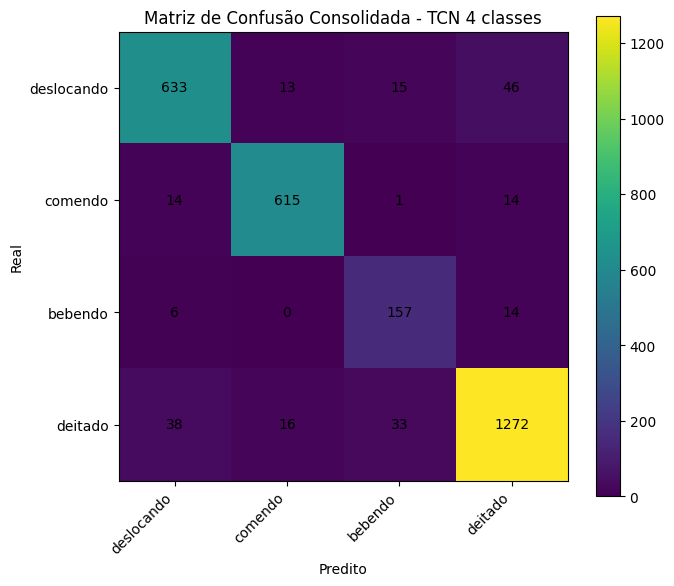


Arquivos salvos em:
C:\Degcn-yolo\Doutorado\experimentos\tcn_vel_4classes_5fold_same_splits_as_degcn


In [26]:
# %% Resultado consolidado - TCN com posição + velocidade (4 classes agrupadas)***********Melhor 4 classes***************
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# =========================================================
# PATHS
# =========================================================
SAVE_DIR = Path(r"C:\Degcn-yolo\Doutorado\experimentos\tcn_vel_4classes_5fold_same_splits_as_degcn")
BASE = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes")
MAP_PATH = BASE / "labels_map_4c.json"

with open(MAP_PATH, "r", encoding="utf-8") as f:
    label_map = json.load(f)

class_to_idx = label_map["class_to_idx"]
idx_to_class = {int(v): k for k, v in class_to_idx.items()}
num_classes = len(idx_to_class)
class_names = [idx_to_class[i] for i in range(num_classes)]

# =========================================================
# SOMAR MATRIZES DE CONFUSÃO DOS 5 FOLDS
# =========================================================
cm_total = np.zeros((num_classes, num_classes), dtype=np.int64)
fold_summary = []

for fold in range(5):
    fold_dir = SAVE_DIR / f"fold{fold}"
    cm_path = fold_dir / "confusion_matrix.npy"
    hist_path = fold_dir / "history.csv"

    if not cm_path.exists():
        raise FileNotFoundError(f"Não encontrei: {cm_path}")

    cm = np.load(cm_path)
    cm_total += cm

    row = {"fold": fold}
    if hist_path.exists():
        hist = pd.read_csv(hist_path)
        best_idx = hist["val_f1"].idxmax()
        row["best_epoch"] = int(hist.loc[best_idx, "epoch"])
        row["best_val_acc"] = float(hist.loc[best_idx, "val_acc"])
        row["best_val_f1"] = float(hist.loc[best_idx, "val_f1"])
    fold_summary.append(row)

fold_summary_df = pd.DataFrame(fold_summary)

# =========================================================
# RECONSTRUIR y_true / y_pred A PARTIR DA MATRIZ
# =========================================================
all_true = []
all_pred = []

for i in range(num_classes):
    for j in range(num_classes):
        n = cm_total[i, j]
        if n > 0:
            all_true.extend([i] * n)
            all_pred.extend([j] * n)

all_true = np.array(all_true, dtype=np.int64)
all_pred = np.array(all_pred, dtype=np.int64)

# =========================================================
# MÉTRICAS GLOBAIS
# =========================================================
acc = accuracy_score(all_true, all_pred)
macro_precision = precision_score(
    all_true, all_pred,
    average="macro",
    labels=list(range(num_classes)),
    zero_division=0
)
macro_recall = recall_score(
    all_true, all_pred,
    average="macro",
    labels=list(range(num_classes)),
    zero_division=0
)
macro_f1 = f1_score(
    all_true, all_pred,
    average="macro",
    labels=list(range(num_classes)),
    zero_division=0
)
weighted_f1 = f1_score(
    all_true, all_pred,
    average="weighted",
    labels=list(range(num_classes)),
    zero_division=0
)

report = classification_report(
    all_true,
    all_pred,
    labels=list(range(num_classes)),
    target_names=class_names,
    digits=4,
    zero_division=0,
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()

# =========================================================
# SALVAR
# =========================================================
np.save(SAVE_DIR / "confusion_matrix_consolidated.npy", cm_total)
fold_summary_df.to_csv(SAVE_DIR / "summary_5fold_rebuilt.csv", index=False)
report_df.to_csv(SAVE_DIR / "classification_report_consolidated.csv")

metrics_df = pd.DataFrame([{
    "accuracy": acc,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
    "n_samples_total": len(all_true),
}])
metrics_df.to_csv(SAVE_DIR / "metrics_consolidated.csv", index=False)

# =========================================================
# EXIBIR RESULTADOS
# =========================================================
print("=" * 80)
print("RESULTADO FINAL — TCN COM POSIÇÃO + VELOCIDADE (4 CLASSES)")
print("=" * 80)
print(f"Acurácia        : {acc:.6f}")
print(f"Macro Precision : {macro_precision:.6f}")
print(f"Macro Recall    : {macro_recall:.6f}")
print(f"Macro F1        : {macro_f1:.6f}")
print(f"Weighted F1     : {weighted_f1:.6f}")
print(f"N amostras      : {len(all_true)}")

print("\nResumo por fold:")
display(fold_summary_df)

print("\nRelatório consolidado por classe:")
display(report_df)

print("\nMatriz de confusão consolidada:")
cm_df = pd.DataFrame(cm_total, index=class_names, columns=class_names)
display(cm_df)

# =========================================================
# PLOT DA MATRIZ DE CONFUSÃO
# =========================================================
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_total)

ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predito")
ax.set_ylabel("Real")
ax.set_title("Matriz de Confusão Consolidada - TCN 4 classes")

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, str(cm_total[i, j]), ha="center", va="center")

plt.colorbar(im)
plt.tight_layout()
plt.show()

print("\nArquivos salvos em:")
print(SAVE_DIR)

## Train the four-class TCN with position and velocity features

This cell trains and evaluates the TCN under the four-class behavioral scenario using the same five temporal folds. It follows the same strategy used in the six-class setting: model definition, class weighting, fold-wise training, validation prediction, metric computation, and result export. This allows a fair assessment of how class aggregation affects TCN performance.


RESULTADO FINAL — TCN COM POSIÇÃO + VELOCIDADE (4 CLASSES, best ACC)
Acurácia        : 0.927607
Macro Precision : 0.883545
Macro Recall    : 0.919414
Macro F1        : 0.898918
Weighted F1     : 0.928890
N amostras      : 2887

Resumo por fold:


,fold,best_epoch,best_val_acc,best_val_f1
0,0,59,0.914798,0.861071
1,1,28,0.914516,0.836209
2,2,53,0.960808,0.900539
3,3,52,0.914432,0.874764
4,4,2,0.908163,0.237968



Relatório consolidado por classe:


,precision,recall,f1-score,support
deslocando,0.908062,0.908062,0.908062,707.000000
comendo,0.973479,0.968944,0.971206,644.000000
bebendo,0.698198,0.875706,0.776942,177.000000
deitado,0.954442,0.924945,0.939462,1359.000000
accuracy,0.927607,0.927607,0.927607,0.927607
macro avg,0.883545,0.919414,0.898918,2887.000000
weighted avg,0.931620,0.927607,0.928890,2887.000000



Matriz de confusão consolidada:


,deslocando,comendo,bebendo,deitado
deslocando,642,11,17,37
comendo,11,624,1,8
bebendo,7,0,155,15
deitado,47,6,49,1257


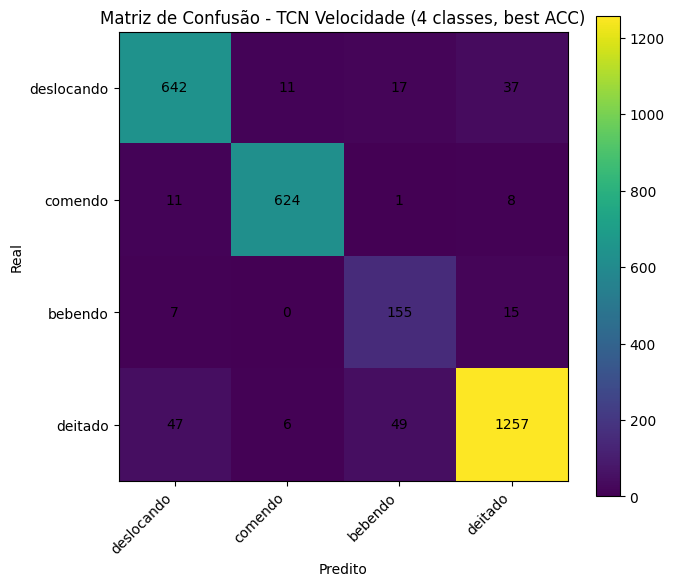


Arquivos salvos em:
C:\Degcn-yolo\Doutorado\experimentos\tcn_vel_4classes_bestacc


In [37]:
# %% Resultado consolidado - TCN (posição + velocidade) 4 classes - best ACC
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# =========================================================
# PATHS
# =========================================================
SAVE_DIR = Path(r"C:\Degcn-yolo\Doutorado\experimentos\tcn_vel_4classes_bestacc")
BASE = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes")
MAP_PATH = BASE / "labels_map_4c.json"

with open(MAP_PATH, "r", encoding="utf-8") as f:
    label_map = json.load(f)

class_to_idx = label_map["class_to_idx"]
idx_to_class = {int(v): k for k, v in class_to_idx.items()}
num_classes = len(idx_to_class)
class_names = [idx_to_class[i] for i in range(num_classes)]

# =========================================================
# SOMAR MATRIZES DE CONFUSÃO DOS 5 FOLDS
# =========================================================
cm_total = np.zeros((num_classes, num_classes), dtype=np.int64)
fold_summary = []

for fold in range(5):
    fold_dir = SAVE_DIR / f"fold{fold}"
    cm_path = fold_dir / "confusion_matrix.npy"
    hist_path = fold_dir / "history.csv"

    if not cm_path.exists():
        raise FileNotFoundError(f"Não encontrei: {cm_path}")

    cm = np.load(cm_path)
    cm_total += cm

    row = {"fold": fold}
    if hist_path.exists():
        hist = pd.read_csv(hist_path)
        best_idx = hist["val_acc"].idxmax()
        row["best_epoch"] = int(hist.loc[best_idx, "epoch"])
        row["best_val_acc"] = float(hist.loc[best_idx, "val_acc"])
        row["best_val_f1"] = float(hist.loc[best_idx, "val_f1"])
    fold_summary.append(row)

fold_summary_df = pd.DataFrame(fold_summary)

# =========================================================
# RECONSTRUIR y_true / y_pred A PARTIR DA MATRIZ
# =========================================================
all_true = []
all_pred = []

for i in range(num_classes):
    for j in range(num_classes):
        n = cm_total[i, j]
        if n > 0:
            all_true.extend([i] * n)
            all_pred.extend([j] * n)

all_true = np.array(all_true, dtype=np.int64)
all_pred = np.array(all_pred, dtype=np.int64)

# =========================================================
# MÉTRICAS GLOBAIS
# =========================================================
acc = accuracy_score(all_true, all_pred)
macro_precision = precision_score(
    all_true, all_pred,
    average="macro",
    labels=list(range(num_classes)),
    zero_division=0
)
macro_recall = recall_score(
    all_true, all_pred,
    average="macro",
    labels=list(range(num_classes)),
    zero_division=0
)
macro_f1 = f1_score(
    all_true, all_pred,
    average="macro",
    labels=list(range(num_classes)),
    zero_division=0
)
weighted_f1 = f1_score(
    all_true, all_pred,
    average="weighted",
    labels=list(range(num_classes)),
    zero_division=0
)

report = classification_report(
    all_true,
    all_pred,
    labels=list(range(num_classes)),
    target_names=class_names,
    digits=4,
    zero_division=0,
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()

# =========================================================
# SALVAR
# =========================================================
np.save(SAVE_DIR / "confusion_matrix_consolidated.npy", cm_total)
fold_summary_df.to_csv(SAVE_DIR / "summary_5fold_rebuilt.csv", index=False)
report_df.to_csv(SAVE_DIR / "classification_report_consolidated.csv")

metrics_df = pd.DataFrame([{
    "accuracy": acc,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
    "n_samples_total": len(all_true),
}])
metrics_df.to_csv(SAVE_DIR / "metrics_consolidated.csv", index=False)

# =========================================================
# EXIBIR RESULTADOS
# =========================================================
print("=" * 80)
print("RESULTADO FINAL — TCN COM POSIÇÃO + VELOCIDADE (4 CLASSES, best ACC)")
print("=" * 80)
print(f"Acurácia        : {acc:.6f}")
print(f"Macro Precision : {macro_precision:.6f}")
print(f"Macro Recall    : {macro_recall:.6f}")
print(f"Macro F1        : {macro_f1:.6f}")
print(f"Weighted F1     : {weighted_f1:.6f}")
print(f"N amostras      : {len(all_true)}")

print("\nResumo por fold:")
display(fold_summary_df)

print("\nRelatório consolidado por classe:")
display(report_df)

print("\nMatriz de confusão consolidada:")
cm_df = pd.DataFrame(cm_total, index=class_names, columns=class_names)
display(cm_df)

# =========================================================
# PLOT DA MATRIZ
# =========================================================
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_total)

ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predito")
ax.set_ylabel("Real")
ax.set_title("Matriz de Confusão - TCN Velocidade (4 classes, best ACC)")

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, str(cm_total[i, j]), ha="center", va="center")

plt.colorbar(im)
plt.tight_layout()
plt.show()

print("\nArquivos salvos em:")
print(SAVE_DIR)

# Random Forest  6 classes


## Consolidate four-class TCN results

This cell aggregates the fold-level outputs for the four-class TCN experiment. It combines predictions and confusion matrices from all folds and computes consolidated evaluation metrics. The resulting summaries are used to compare the four-class TCN against DeGCN, Random Forest, and image-based baselines.


In [1]:
# %% Random Forest 5-fold temporal CV - 6 classes
# Mesmas variáveis do TCN: posição + velocidade

import json
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# =========================================================
# PATHS - 6 CLASSES
# =========================================================
BASE = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15")

X_PATH = BASE / "data_valid_tcn_vel.npy"     # (N, T, F) posição + velocidade
Y_PATH = BASE / "labels_valid.npy"
MAP_PATH = BASE / "labels_mix_map.json"
SPLITS = BASE / "splits_temporal_5fold_blocks"

SAVE_DIR = Path(r"C:\Degcn-yolo\Doutorado\experimentos\rf_pos_vel_6classes_5fold_same_splits_as_degcn")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# LOAD
# =========================================================
X_all = np.load(X_PATH).astype(np.float32)   # (N, T, F)
y_all = np.load(Y_PATH).astype(np.int64)

with open(MAP_PATH, "r", encoding="utf-8") as f:
    label_map = json.load(f)

class_to_idx = label_map["class_to_idx"]
idx_to_class = {int(v): k for k, v in class_to_idx.items()}
num_classes = len(idx_to_class)
class_names = [idx_to_class[i] for i in range(num_classes)]

print("X original:", X_all.shape)
print("y:", y_all.shape)
print("Classes:", idx_to_class)

# =========================================================
# ACHATAR PARA RANDOM FOREST
# (N, T, F) -> (N, T*F)
# =========================================================
N, T, F = X_all.shape
X_rf = X_all.reshape(N, T * F)

print("\nX para Random Forest:", X_rf.shape)
print("Número de variáveis por amostra:", X_rf.shape[1])

# =========================================================
# LOOP 5-FOLD
# =========================================================
fold_rows = []
cm_total = np.zeros((num_classes, num_classes), dtype=np.int64)

all_true = []
all_pred = []

for fold in range(5):
    print("\n" + "=" * 80)
    print(f"FOLD {fold}")
    print("=" * 80)

    train_idx = np.load(SPLITS / f"fold{fold}_train_idx.npy")
    val_idx   = np.load(SPLITS / f"fold{fold}_val_idx.npy")

    X_train, y_train = X_rf[train_idx], y_all[train_idx]
    X_val, y_val     = X_rf[val_idx], y_all[val_idx]

    print("X_train:", X_train.shape)
    print("X_val  :", X_val.shape)
    print("Interseção:", len(np.intersect1d(train_idx, val_idx)))

    # =====================================================
    # MODELO RANDOM FOREST
    # =====================================================
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight="balanced",
        bootstrap=True,
        n_jobs=-1,
        random_state=fold,
        verbose=1
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    macro_precision = precision_score(
        y_val, y_pred,
        average="macro",
        labels=list(range(num_classes)),
        zero_division=0
    )
    macro_recall = recall_score(
        y_val, y_pred,
        average="macro",
        labels=list(range(num_classes)),
        zero_division=0
    )
    macro_f1 = f1_score(
        y_val, y_pred,
        average="macro",
        labels=list(range(num_classes)),
        zero_division=0
    )
    weighted_f1 = f1_score(
        y_val, y_pred,
        average="weighted",
        labels=list(range(num_classes)),
        zero_division=0
    )

    cm = confusion_matrix(
        y_val,
        y_pred,
        labels=list(range(num_classes))
    )

    cm_total += cm
    all_true.extend(y_val.tolist())
    all_pred.extend(y_pred.tolist())

    fold_dir = SAVE_DIR / f"fold{fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    np.save(fold_dir / "confusion_matrix.npy", cm)
    np.save(fold_dir / "y_true.npy", y_val)
    np.save(fold_dir / "y_pred.npy", y_pred)

    report = classification_report(
        y_val,
        y_pred,
        labels=list(range(num_classes)),
        target_names=class_names,
        digits=4,
        zero_division=0,
        output_dict=True
    )

    pd.DataFrame(report).transpose().to_csv(
        fold_dir / "classification_report.csv"
    )

    fold_row = {
        "fold": fold,
        "accuracy": acc,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "n_train": len(train_idx),
        "n_val": len(val_idx),
    }

    fold_rows.append(fold_row)

    print("\nResultado do fold:")
    print(fold_row)

# =========================================================
# RESULTADO CONSOLIDADO
# =========================================================
all_true = np.array(all_true, dtype=np.int64)
all_pred = np.array(all_pred, dtype=np.int64)

summary_df = pd.DataFrame(fold_rows)
summary_df.to_csv(SAVE_DIR / "summary_5fold.csv", index=False)

np.save(SAVE_DIR / "confusion_matrix_consolidated.npy", cm_total)
np.save(SAVE_DIR / "y_true_consolidated.npy", all_true)
np.save(SAVE_DIR / "y_pred_consolidated.npy", all_pred)

acc_global = accuracy_score(all_true, all_pred)
macro_precision_global = precision_score(
    all_true, all_pred,
    average="macro",
    labels=list(range(num_classes)),
    zero_division=0
)
macro_recall_global = recall_score(
    all_true, all_pred,
    average="macro",
    labels=list(range(num_classes)),
    zero_division=0
)
macro_f1_global = f1_score(
    all_true, all_pred,
    average="macro",
    labels=list(range(num_classes)),
    zero_division=0
)
weighted_f1_global = f1_score(
    all_true, all_pred,
    average="weighted",
    labels=list(range(num_classes)),
    zero_division=0
)

metrics_df = pd.DataFrame([{
    "accuracy": acc_global,
    "macro_precision": macro_precision_global,
    "macro_recall": macro_recall_global,
    "macro_f1": macro_f1_global,
    "weighted_f1": weighted_f1_global,
    "n_samples_total": len(all_true),
}])

metrics_df.to_csv(SAVE_DIR / "metrics_consolidated.csv", index=False)

report_global = classification_report(
    all_true,
    all_pred,
    labels=list(range(num_classes)),
    target_names=class_names,
    digits=4,
    zero_division=0,
    output_dict=True
)

report_global_df = pd.DataFrame(report_global).transpose()
report_global_df.to_csv(SAVE_DIR / "classification_report_consolidated.csv")

cm_df = pd.DataFrame(cm_total, index=class_names, columns=class_names)
cm_df.to_csv(SAVE_DIR / "confusion_matrix_consolidated.csv")

print("\n" + "=" * 80)
print("RESULTADO FINAL — RANDOM FOREST — 6 CLASSES — POSIÇÃO + VELOCIDADE")
print("=" * 80)

print("\nMédia ± DP entre folds:")
print(f"Accuracy : {summary_df['accuracy'].mean():.4f} ± {summary_df['accuracy'].std(ddof=1):.4f}")
print(f"Macro-F1 : {summary_df['macro_f1'].mean():.4f} ± {summary_df['macro_f1'].std(ddof=1):.4f}")

print("\nMétricas consolidadas:")
print(f"Acurácia        : {acc_global:.6f}")
print(f"Macro Precision : {macro_precision_global:.6f}")
print(f"Macro Recall    : {macro_recall_global:.6f}")
print(f"Macro F1        : {macro_f1_global:.6f}")
print(f"Weighted F1     : {weighted_f1_global:.6f}")
print(f"N amostras      : {len(all_true)}")

print("\nRelatório consolidado por classe:")
display(report_global_df)

print("\nMatriz de confusão consolidada:")
display(cm_df)

print("\nArquivos salvos em:")
print(SAVE_DIR)

X original: (2887, 15, 36)
y: (2887,)
Classes: {0: 'walking', 1: 'running', 2: 'eating', 3: 'drinking', 4: 'lying awake', 5: 'sleeping'}

X para Random Forest: (2887, 540)
Número de variáveis por amostra: 540

FOLD 0
X_train: (2441, 540)
X_val  : (446, 540)
Interseção: 0


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 410 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    2.9s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 500 out of 500 | elapsed:    0.1s finished



Resultado do fold:
{'fold': 0, 'accuracy': 0.6614349775784754, 'macro_precision': 0.6594331447111522, 'macro_recall': 0.7566022057933078, 'macro_f1': 0.6585092966671914, 'weighted_f1': 0.6683664367166845, 'n_train': 2441, 'n_val': 446}

FOLD 1
X_train: (2267, 540)
X_val  : (620, 540)
Interseção: 0


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 410 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    2.6s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 500 out of 500 | elapsed:    0.1s finished



Resultado do fold:
{'fold': 1, 'accuracy': 0.8064516129032258, 'macro_precision': 0.6811319730166141, 'macro_recall': 0.6748179825488786, 'macro_f1': 0.6772475972772964, 'weighted_f1': 0.8087387082819771, 'n_train': 2267, 'n_val': 620}

FOLD 2
X_train: (2045, 540)
X_val  : (842, 540)
Interseção: 0


...


Resultado do fold:
{'fold': 4, 'accuracy': 0.42346938775510207, 'macro_precision': 0.20804642927405073, 'macro_recall': 0.34382284382284384, 'macro_f1': 0.1758147916244095, 'weighted_f1': 0.44372735998352847, 'n_train': 2691, 'n_val': 196}

RESULTADO FINAL — RANDOM FOREST — 6 CLASSES — POSIÇÃO + VELOCIDADE

Média ± DP entre folds:
Accuracy : 0.6775 ± 0.1567
Macro-F1 : 0.5741 ± 0.2231

Métricas consolidadas:
Acurácia        : 0.726360
Macro Precision : 0.711083
Macro Recall    : 0.707182
Macro F1        : 0.706977
Weighted F1     : 0.724493
N amostras      : 2887

Relatório consolidado por classe:


,precision,recall,f1-score,support
walking,0.566079,0.647355,0.603995,397.00000
running,0.595745,0.451613,0.513761,310.00000
eating,0.962848,0.965839,0.964341,644.00000
drinking,0.803279,0.830508,0.816667,177.00000
lying awake,0.599309,0.595197,0.597246,583.00000
sleeping,0.739241,0.752577,0.745849,776.00000
accuracy,0.726360,0.726360,0.726360,0.72636
macro avg,0.711083,0.707182,0.706977,2887.00000
weighted avg,0.725569,0.726360,0.724493,2887.00000



Matriz de confusão consolidada:


,walking,running,eating,drinking,lying awake,sleeping
walking,257,89,5,4,34,8
running,139,140,12,0,14,5
eating,4,4,622,1,4,9
drinking,10,0,0,147,10,10
lying awake,39,2,2,19,347,174
sleeping,5,0,5,12,170,584



Arquivos salvos em:
C:\Degcn-yolo\Doutorado\experimentos\rf_pos_vel_6classes_5fold_same_splits_as_degcn


## Train and evaluate the six-class Random Forest baseline

This cell implements a Random Forest classifier using the same keypoint position-plus-velocity representation as the TCN. The temporal sequence is flattened into a single feature vector per sample, which is appropriate for tree-based models. The Random Forest is trained and evaluated across the same five temporal folds, providing a classical machine-learning baseline for comparison with neural temporal models.


In [4]:
# %% Criar dataset 4 classes a partir do dataset 6 classes
# Agrupamento:
# walking + running -> locomotion
# eating            -> eating
# drinking          -> drinking
# lying awake + sleeping -> lying

import json
import shutil
from pathlib import Path

import numpy as np
import pandas as pd

# =========================================================
# PASTAS
# =========================================================
BASE6 = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15")
BASE4 = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes")

BASE4.mkdir(parents=True, exist_ok=True)

# =========================================================
# ARQUIVOS DA BASE ORIGINAL 6 CLASSES
# =========================================================
DATA6_PATH = BASE6 / "data_valid.npy"
LABELS6_PATH = BASE6 / "labels_valid.npy"
META6_PATH = BASE6 / "meta_valid.csv"
MAP6_PATH = BASE6 / "labels_mix_map.json"
SPLITS6 = BASE6 / "splits_temporal_5fold_blocks"

# =========================================================
# ARQUIVOS DE SAÍDA 4 CLASSES
# =========================================================
DATA4_PATH = BASE4 / "data_valid.npy"
LABELS4_PATH = BASE4 / "labels_valid.npy"
META4_PATH = BASE4 / "meta_valid.csv"
MAP4_PATH = BASE4 / "labels_map_4c.json"
SPLITS4 = BASE4 / "splits_temporal_5fold_blocks"

# =========================================================
# LOAD
# =========================================================
X6 = np.load(DATA6_PATH)
y6 = np.load(LABELS6_PATH)

meta6 = pd.read_csv(META6_PATH)

with open(MAP6_PATH, "r", encoding="utf-8") as f:
    map6 = json.load(f)

class_to_idx6 = map6["class_to_idx"]
idx_to_class6 = {int(v): k for k, v in class_to_idx6.items()}

print("Classes originais 6 classes:")
print(idx_to_class6)

# =========================================================
# NORMALIZAR NOMES DAS CLASSES
# =========================================================
def norm_name(s):
    return str(s).lower().replace("_", " ").strip()

idx_to_class6_norm = {i: norm_name(c) for i, c in idx_to_class6.items()}

print("\nClasses normalizadas:")
for i, c in idx_to_class6_norm.items():
    print(i, "->", c)

# =========================================================
# MAPA 6 CLASSES -> 4 CLASSES
# =========================================================
new_class_to_idx = {
    "locomotion": 0,
    "eating": 1,
    "drinking": 2,
    "lying": 3,
}

def map_6_to_4(old_label):
    old_name = idx_to_class6_norm[int(old_label)]

    if old_name in ["walking", "running"]:
        return new_class_to_idx["locomotion"]

    elif old_name == "eating":
        return new_class_to_idx["eating"]

    elif old_name == "drinking":
        return new_class_to_idx["drinking"]

    elif old_name in ["lying awake", "sleeping"]:
        return new_class_to_idx["lying"]

    else:
        raise ValueError(f"Classe não reconhecida: {old_name}")

y4 = np.array([map_6_to_4(label) for label in y6], dtype=np.int64)

# =========================================================
# SALVAR X E y
# X é o mesmo; apenas os rótulos mudam
# =========================================================
np.save(DATA4_PATH, X6)
np.save(LABELS4_PATH, y4)

# salvar meta também
meta6.to_csv(META4_PATH, index=False)

# salvar mapa 4 classes
map4 = {
    "class_to_idx": new_class_to_idx,
    "idx_to_class": {str(v): k for k, v in new_class_to_idx.items()},
    "grouping": {
        "locomotion": ["walking", "running"],
        "eating": ["eating"],
        "drinking": ["drinking"],
        "lying": ["lying awake", "sleeping"],
    }
}

with open(MAP4_PATH, "w", encoding="utf-8") as f:
    json.dump(map4, f, indent=4, ensure_ascii=False)

# =========================================================
# COPIAR OS MESMOS SPLITS TEMPORAIS
# =========================================================
SPLITS4.mkdir(parents=True, exist_ok=True)

for fold in range(5):
    shutil.copy2(
        SPLITS6 / f"fold{fold}_train_idx.npy",
        SPLITS4 / f"fold{fold}_train_idx.npy"
    )
    shutil.copy2(
        SPLITS6 / f"fold{fold}_val_idx.npy",
        SPLITS4 / f"fold{fold}_val_idx.npy"
    )

# =========================================================
# CHECKS
# =========================================================
print("\nArquivos criados:")
print(DATA4_PATH)
print(LABELS4_PATH)
print(META4_PATH)
print(MAP4_PATH)
print(SPLITS4)

print("\nShape X4:", X6.shape)
print("Shape y4:", y4.shape)

print("\nDistribuição das 4 classes:")
idx_to_class4 = {v: k for k, v in new_class_to_idx.items()}

unique, counts = np.unique(y4, return_counts=True)

for u, c in zip(unique, counts):
    print(f"{u} - {idx_to_class4[int(u)]:12s}: {c}")

Classes originais 6 classes:
{0: 'walking', 1: 'running', 2: 'eating', 3: 'drinking', 4: 'lying awake', 5: 'sleeping'}

Classes normalizadas:
0 -> walking
1 -> running
2 -> eating
3 -> drinking
4 -> lying awake
5 -> sleeping

Arquivos criados:
C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes\data_valid.npy
C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes\labels_valid.npy
C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes\meta_valid.csv
C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes\labels_map_4c.json
C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes\splits_temporal_5fold_blocks

Shape X4: (2887, 2, 15, 9, 1)
Shape y4: (2887,)

Distribuição das 4 classes:
0 - locomotion  : 707
1 - eating      : 644
2 - drinking    : 177
3 - lying       : 1359


## Analyze Random Forest outputs for the six-class scenario

This cell consolidates Random Forest results for the six-class task. It loads fold-level predictions or metrics, computes aggregate performance indicators, and prepares outputs such as classification reports or confusion matrices. These results help determine whether a simpler non-deep-learning baseline can compete with temporal neural models on the keypoint representation.


In [5]:
# %% Criar data_valid_tcn_vel.npy para o dataset de 4 classes

import numpy as np
from pathlib import Path

BASE4 = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes")

DATA_PATH = BASE4 / "data_valid.npy"
OUT_POS_PATH = BASE4 / "data_valid_tcn.npy"
OUT_VEL_PATH = BASE4 / "data_valid_tcn_vel.npy"

X = np.load(DATA_PATH).astype(np.float32)

print("X original:", X.shape)

assert X.ndim == 5, f"Esperado X no formato (N,C,T,V,M), veio {X.shape}"

N, C, T, V, M = X.shape
assert M == 1, f"Esperado M=1, veio M={M}"

# =========================================================
# POSIÇÃO: (N,C,T,V,M) -> (N,T,C*V)
# =========================================================
X_pos = X[..., 0]                         # (N, C, T, V)
X_pos = np.transpose(X_pos, (0, 2, 1, 3)) # (N, T, C, V)
X_pos = X_pos.reshape(N, T, C * V)        # (N, T, F)

# =========================================================
# VELOCIDADE
# =========================================================
X_vel = np.zeros_like(X_pos, dtype=np.float32)
X_vel[:, 1:, :] = X_pos[:, 1:, :] - X_pos[:, :-1, :]
X_vel[:, 0, :] = 0.0

# =========================================================
# POSIÇÃO + VELOCIDADE
# =========================================================
X_tcn_vel = np.concatenate([X_pos, X_vel], axis=2).astype(np.float32)

np.save(OUT_POS_PATH, X_pos.astype(np.float32))
np.save(OUT_VEL_PATH, X_tcn_vel)

print("X_pos     :", X_pos.shape)
print("X_vel     :", X_vel.shape)
print("X_tcn_vel :", X_tcn_vel.shape)

print("\nArquivos salvos:")
print(OUT_POS_PATH)
print(OUT_VEL_PATH)

print("\nEstatísticas:")
print("min :", X_tcn_vel.min())
print("max :", X_tcn_vel.max())
print("mean:", X_tcn_vel.mean())
print("std :", X_tcn_vel.std())

X original: (2887, 2, 15, 9, 1)
X_pos     : (2887, 15, 18)
X_vel     : (2887, 15, 18)
X_tcn_vel : (2887, 15, 36)

Arquivos salvos:
C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes\data_valid_tcn.npy
C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes\data_valid_tcn_vel.npy

Estatísticas:
min : -0.41252083
max : 1.0
mean: 0.28677982
std : 0.34859496


## Create the four-class dataset from the six-class skeleton data

This cell creates a complete four-class version of the dataset directly from the original six-class skeleton arrays. It applies the behavioral grouping rules, saves the new labels and mapping file, and copies the corresponding metadata and temporal split files. This ensures that all four-class experiments share a consistent dataset representation.


In [6]:
# %% Conferir dataset 4 classes criado

import json
import numpy as np
from pathlib import Path

BASE4 = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes")

arquivos = [
    "data_valid.npy",
    "data_valid_tcn.npy",
    "data_valid_tcn_vel.npy",
    "labels_valid.npy",
    "labels_map_4c.json",
]

for nome in arquivos:
    path = BASE4 / nome
    print(nome, "->", path.exists())

X = np.load(BASE4 / "data_valid_tcn_vel.npy")
y = np.load(BASE4 / "labels_valid.npy")

with open(BASE4 / "labels_map_4c.json", "r", encoding="utf-8") as f:
    label_map = json.load(f)

class_to_idx = label_map["class_to_idx"]
idx_to_class = {int(v): k for k, v in class_to_idx.items()}

print("\nX:", X.shape)
print("y:", y.shape)
print("Classes:", idx_to_class)

print("\nDistribuição:")
unique, counts = np.unique(y, return_counts=True)

for u, c in zip(unique, counts):
    print(f"{u} - {idx_to_class[int(u)]:12s}: {c}")

data_valid.npy -> True
data_valid_tcn.npy -> True
data_valid_tcn_vel.npy -> True
labels_valid.npy -> True
labels_map_4c.json -> True

X: (2887, 15, 36)
y: (2887,)
Classes: {0: 'locomotion', 1: 'eating', 2: 'drinking', 3: 'lying'}

Distribuição:
0 - locomotion  : 707
1 - eating      : 644
2 - drinking    : 177
3 - lying       : 1359


## Create position and velocity arrays for the four-class dataset

This cell generates the TCN-compatible feature arrays for the four-class dataset. It produces both the position-only representation and the position-plus-velocity representation. These arrays are required for the four-class TCN and Random Forest experiments and maintain the same temporal window structure as the original DeGCN data.


In [7]:
# %% Conferir dataset 4 classes criado

import json
import numpy as np
from pathlib import Path

BASE4 = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes")

arquivos = [
    "data_valid.npy",
    "data_valid_tcn.npy",
    "data_valid_tcn_vel.npy",
    "labels_valid.npy",
    "labels_map_4c.json",
]

for nome in arquivos:
    path = BASE4 / nome
    print(nome, "->", path.exists())

X = np.load(BASE4 / "data_valid_tcn_vel.npy")
y = np.load(BASE4 / "labels_valid.npy")

with open(BASE4 / "labels_map_4c.json", "r", encoding="utf-8") as f:
    label_map = json.load(f)

class_to_idx = label_map["class_to_idx"]
idx_to_class = {int(v): k for k, v in class_to_idx.items()}

print("\nX:", X.shape)
print("y:", y.shape)
print("Classes:", idx_to_class)

print("\nDistribuição:")
unique, counts = np.unique(y, return_counts=True)

for u, c in zip(unique, counts):
    print(f"{u} - {idx_to_class[int(u)]:12s}: {c}")

data_valid.npy -> True
data_valid_tcn.npy -> True
data_valid_tcn_vel.npy -> True
labels_valid.npy -> True
labels_map_4c.json -> True

X: (2887, 15, 36)
y: (2887,)
Classes: {0: 'locomotion', 1: 'eating', 2: 'drinking', 3: 'lying'}

Distribuição:
0 - locomotion  : 707
1 - eating      : 644
2 - drinking    : 177
3 - lying       : 1359


## Validate the generated four-class dataset

This cell checks that the four-class dataset was created correctly. It verifies that all required files exist, loads the position-plus-velocity array and labels, reads the class mapping, and prints class distributions. This is a quality-control step before training four-class models.


In [8]:
# %% Random Forest 5-fold temporal CV - 4 classes
# Classes:
# locomotion = walking + running
# eating
# drinking
# lying = lying awake + sleeping

import json
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# =========================================================
# PATHS - 4 CLASSES
# =========================================================
BASE = Path(r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes")

X_PATH = BASE / "data_valid_tcn_vel.npy"
Y_PATH = BASE / "labels_valid.npy"
MAP_PATH = BASE / "labels_map_4c.json"
SPLITS = BASE / "splits_temporal_5fold_blocks"

SAVE_DIR = Path(r"C:\Degcn-yolo\Doutorado\experimentos\rf_pos_vel_4classes_5fold_same_splits_as_degcn")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# LOAD
# =========================================================
X_all = np.load(X_PATH).astype(np.float32)   # (N, T, F)
y_all = np.load(Y_PATH).astype(np.int64)

with open(MAP_PATH, "r", encoding="utf-8") as f:
    label_map = json.load(f)

class_to_idx = label_map["class_to_idx"]
idx_to_class = {int(v): k for k, v in class_to_idx.items()}
num_classes = len(idx_to_class)
class_names = [idx_to_class[i] for i in range(num_classes)]

print("X original:", X_all.shape)
print("y:", y_all.shape)
print("Classes:", idx_to_class)

# =========================================================
# ACHATAR PARA RANDOM FOREST
# (N, T, F) -> (N, T*F)
# =========================================================
N, T, F = X_all.shape
X_rf = X_all.reshape(N, T * F)

print("\nX para Random Forest:", X_rf.shape)
print("Número de variáveis por amostra:", X_rf.shape[1])

# =========================================================
# LOOP 5-FOLD TEMPORAL
# =========================================================
fold_rows = []
cm_total = np.zeros((num_classes, num_classes), dtype=np.int64)

all_true = []
all_pred = []

for fold in range(5):
    print("\n" + "=" * 80)
    print(f"FOLD {fold}")
    print("=" * 80)

    train_idx = np.load(SPLITS / f"fold{fold}_train_idx.npy")
    val_idx   = np.load(SPLITS / f"fold{fold}_val_idx.npy")

    X_train, y_train = X_rf[train_idx], y_all[train_idx]
    X_val, y_val     = X_rf[val_idx], y_all[val_idx]

    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_val  :", X_val.shape)
    print("y_val  :", y_val.shape)
    print("Interseção:", len(np.intersect1d(train_idx, val_idx)))

    # =====================================================
    # RANDOM FOREST
    # =====================================================
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight="balanced",
        bootstrap=True,
        n_jobs=-1,
        random_state=fold,
        verbose=1
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_val)

    # =====================================================
    # MÉTRICAS DO FOLD
    # =====================================================
    acc = accuracy_score(y_val, y_pred)

    macro_precision = precision_score(
        y_val, y_pred,
        average="macro",
        labels=list(range(num_classes)),
        zero_division=0
    )

    macro_recall = recall_score(
        y_val, y_pred,
        average="macro",
        labels=list(range(num_classes)),
        zero_division=0
    )

    macro_f1 = f1_score(
        y_val, y_pred,
        average="macro",
        labels=list(range(num_classes)),
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_val, y_pred,
        average="weighted",
        labels=list(range(num_classes)),
        zero_division=0
    )

    cm = confusion_matrix(
        y_val,
        y_pred,
        labels=list(range(num_classes))
    )

    cm_total += cm
    all_true.extend(y_val.tolist())
    all_pred.extend(y_pred.tolist())

    # =====================================================
    # SALVAR FOLD
    # =====================================================
    fold_dir = SAVE_DIR / f"fold{fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    np.save(fold_dir / "confusion_matrix.npy", cm)
    np.save(fold_dir / "y_true.npy", y_val)
    np.save(fold_dir / "y_pred.npy", y_pred)

    report = classification_report(
        y_val,
        y_pred,
        labels=list(range(num_classes)),
        target_names=class_names,
        digits=4,
        zero_division=0,
        output_dict=True
    )

    pd.DataFrame(report).transpose().to_csv(
        fold_dir / "classification_report.csv"
    )

    fold_row = {
        "fold": fold,
        "accuracy": acc,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "n_train": len(train_idx),
        "n_val": len(val_idx),
    }

    fold_rows.append(fold_row)

    print("\nResultado do fold:")
    print(fold_row)

# =========================================================
# RESULTADO CONSOLIDADO
# =========================================================
all_true = np.array(all_true, dtype=np.int64)
all_pred = np.array(all_pred, dtype=np.int64)

summary_df = pd.DataFrame(fold_rows)
summary_df.to_csv(SAVE_DIR / "summary_5fold.csv", index=False)

np.save(SAVE_DIR / "confusion_matrix_consolidated.npy", cm_total)
np.save(SAVE_DIR / "y_true_consolidated.npy", all_true)
np.save(SAVE_DIR / "y_pred_consolidated.npy", all_pred)

acc_global = accuracy_score(all_true, all_pred)

macro_precision_global = precision_score(
    all_true,
    all_pred,
    average="macro",
    labels=list(range(num_classes)),
    zero_division=0
)

macro_recall_global = recall_score(
    all_true,
    all_pred,
    average="macro",
    labels=list(range(num_classes)),
    zero_division=0
)

macro_f1_global = f1_score(
    all_true,
    all_pred,
    average="macro",
    labels=list(range(num_classes)),
    zero_division=0
)

weighted_f1_global = f1_score(
    all_true,
    all_pred,
    average="weighted",
    labels=list(range(num_classes)),
    zero_division=0
)

metrics_df = pd.DataFrame([{
    "accuracy": acc_global,
    "macro_precision": macro_precision_global,
    "macro_recall": macro_recall_global,
    "macro_f1": macro_f1_global,
    "weighted_f1": weighted_f1_global,
    "n_samples_total": len(all_true),
}])

metrics_df.to_csv(SAVE_DIR / "metrics_consolidated.csv", index=False)

report_global = classification_report(
    all_true,
    all_pred,
    labels=list(range(num_classes)),
    target_names=class_names,
    digits=4,
    zero_division=0,
    output_dict=True
)

report_global_df = pd.DataFrame(report_global).transpose()
report_global_df.to_csv(SAVE_DIR / "classification_report_consolidated.csv")

cm_df = pd.DataFrame(cm_total, index=class_names, columns=class_names)
cm_df.to_csv(SAVE_DIR / "confusion_matrix_consolidated.csv")

print("\n" + "=" * 80)
print("RESULTADO FINAL — RANDOM FOREST — 4 CLASSES — POSIÇÃO + VELOCIDADE")
print("=" * 80)

print("\nMédia ± DP entre folds:")
print(f"Accuracy : {summary_df['accuracy'].mean():.4f} ± {summary_df['accuracy'].std(ddof=1):.4f}")
print(f"Macro-F1 : {summary_df['macro_f1'].mean():.4f} ± {summary_df['macro_f1'].std(ddof=1):.4f}")

print("\nMétricas consolidadas:")
print(f"Acurácia        : {acc_global:.6f}")
print(f"Macro Precision : {macro_precision_global:.6f}")
print(f"Macro Recall    : {macro_recall_global:.6f}")
print(f"Macro F1        : {macro_f1_global:.6f}")
print(f"Weighted F1     : {weighted_f1_global:.6f}")
print(f"N amostras      : {len(all_true)}")

print("\nRelatório consolidado por classe:")
display(report_global_df)

print("\nMatriz de confusão consolidada:")
display(cm_df)

print("\nArquivos salvos em:")
print(SAVE_DIR)


X original: (2887, 15, 36)
y: (2887,)
Classes: {0: 'locomotion', 1: 'eating', 2: 'drinking', 3: 'lying'}

X para Random Forest: (2887, 540)
Número de variáveis por amostra: 540

FOLD 0
X_train: (2441, 540)
y_train: (2441,)
X_val  : (446, 540)
y_val  : (446,)
Interseção: 0


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 410 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    2.8s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 500 out of 500 | elapsed:    0.0s finished



Resultado do fold:
{'fold': 0, 'accuracy': 0.8542600896860987, 'macro_precision': 0.8301136363636363, 'macro_recall': 0.7497942266408323, 'macro_f1': 0.7839410936588822, 'weighted_f1': 0.8514364782132879, 'n_train': 2441, 'n_val': 446}

FOLD 1
X_train: (2267, 540)
y_train: (2267,)
X_val  : (620, 540)
y_val  : (620,)
Interseção: 0


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 410 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    2.4s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 500 out of 500 | elapsed:    0.0s finished



Resultado do fold:
{'fold': 1, 'accuracy': 0.95, 'macro_precision': 0.9059596244717518, 'macro_recall': 0.8845520046667823, 'macro_f1': 0.8949066023100075, 'weighted_f1': 0.9495412963650816, 'n_train': 2267, 'n_val': 620}

FOLD 2
X_train: (2045, 540)
y_train: (2045,)
X_val  : (842, 540)
y_val  : (842,)
Interseção: 0


...


Resultado do fold:
{'fold': 4, 'accuracy': 0.8520408163265306, 'macro_precision': 0.24851190476190477, 'macro_recall': 0.2141025641025641, 'macro_f1': 0.23002754820936638, 'weighted_f1': 0.9154157530780908, 'n_train': 2691, 'n_val': 196}

RESULTADO FINAL — RANDOM FOREST — 4 CLASSES — POSIÇÃO + VELOCIDADE

Média ± DP entre folds:
Accuracy : 0.9005 ± 0.0463
Macro-F1 : 0.7334 ± 0.2849

Métricas consolidadas:
Acurácia        : 0.913751
Macro Precision : 0.896439
Macro Recall    : 0.880490
Macro F1        : 0.888145
Weighted F1     : 0.913403
N amostras      : 2887

Relatório consolidado por classe:


,precision,recall,f1-score,support
locomotion,0.886003,0.868458,0.877143,707.000000
eating,0.966877,0.951863,0.959311,644.000000
drinking,0.818182,0.762712,0.789474,177.000000
lying,0.914695,0.938926,0.926652,1359.000000
accuracy,0.913751,0.913751,0.913751,0.913751
macro avg,0.896439,0.880490,0.888145,2887.000000
weighted avg,0.913392,0.913751,0.913403,2887.000000



Matriz de confusão consolidada:


,locomotion,eating,drinking,lying
locomotion,614,15,4,74
eating,17,613,1,13
drinking,10,0,135,32
lying,52,6,25,1276



Arquivos salvos em:
C:\Degcn-yolo\Doutorado\experimentos\rf_pos_vel_4classes_5fold_same_splits_as_degcn


## Repeat validation of the four-class dataset

This cell repeats the four-class dataset validation procedure. Although it duplicates the previous verification, it is useful as an additional checkpoint in the executed notebook because it confirms that the generated files, labels, and class distribution remain accessible before model training.


In [11]:
# %% Calcular complexidade do Random Forest: total de nós e folhas

import json
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

def compute_rf_complexity(base_path, map_filename, scenario_name):
    base_path = Path(base_path)

    X_PATH = base_path / "data_valid_tcn_vel.npy"
    Y_PATH = base_path / "labels_valid.npy"
    MAP_PATH = base_path / map_filename
    SPLITS = base_path / "splits_temporal_5fold_blocks"

    X_all = np.load(X_PATH).astype(np.float32)
    y_all = np.load(Y_PATH).astype(np.int64)

    with open(MAP_PATH, "r", encoding="utf-8") as f:
        label_map = json.load(f)

    class_to_idx = label_map["class_to_idx"]
    num_classes = len(class_to_idx)

    N, T, F = X_all.shape
    X_rf = X_all.reshape(N, T * F)

    rows = []

    for fold in range(5):
        train_idx = np.load(SPLITS / f"fold{fold}_train_idx.npy")

        X_train = X_rf[train_idx]
        y_train = y_all[train_idx]

        rf = RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features="sqrt",
            class_weight="balanced",
            bootstrap=True,
            n_jobs=-1,
            random_state=fold,
            verbose=0
        )

        rf.fit(X_train, y_train)

        total_nodes = sum(est.tree_.node_count for est in rf.estimators_)
        total_leaves = sum(est.tree_.n_leaves for est in rf.estimators_)

        row = {
            "scenario": scenario_name,
            "fold": fold,
            "n_estimators": len(rf.estimators_),
            "input_features": X_rf.shape[1],
            "num_classes": num_classes,
            "total_nodes": total_nodes,
            "total_leaves": total_leaves,
            "mean_nodes_per_tree": total_nodes / len(rf.estimators_),
            "mean_leaves_per_tree": total_leaves / len(rf.estimators_),
        }

        rows.append(row)

        print(f"\n{scenario_name} - Fold {fold}")
        print(f"Total trees          : {len(rf.estimators_)}")
        print(f"Total nodes          : {total_nodes:,}")
        print(f"Total leaves         : {total_leaves:,}")
        print(f"Mean nodes/tree      : {total_nodes / len(rf.estimators_):.2f}")
        print(f"Mean leaves/tree     : {total_leaves / len(rf.estimators_):.2f}")

    df = pd.DataFrame(rows)

    print("\n" + "=" * 80)
    print(f"RESUMO — {scenario_name}")
    print("=" * 80)
    print(f"Total nodes : {df['total_nodes'].mean():.0f} ± {df['total_nodes'].std(ddof=1):.0f}")
    print(f"Total leaves: {df['total_leaves'].mean():.0f} ± {df['total_leaves'].std(ddof=1):.0f}")
    print(f"Nodes/tree  : {df['mean_nodes_per_tree'].mean():.2f} ± {df['mean_nodes_per_tree'].std(ddof=1):.2f}")

    return df


df_rf_complexity_6 = compute_rf_complexity(
    base_path=r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15",
    map_filename="labels_mix_map.json",
    scenario_name="6 classes"
)

df_rf_complexity_4 = compute_rf_complexity(
    base_path=r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes",
    map_filename="labels_map_4c.json",
    scenario_name="4 classes"
)


6 classes - Fold 0
Total trees          : 500
Total nodes          : 300,142
Total leaves         : 150,321
Mean nodes/tree      : 600.28
Mean leaves/tree     : 300.64

6 classes - Fold 1
Total trees          : 500
Total nodes          : 302,786
Total leaves         : 151,643
Mean nodes/tree      : 605.57
Mean leaves/tree     : 303.29

6 classes - Fold 2
Total trees          : 500
Total nodes          : 282,476
Total leaves         : 141,488
Mean nodes/tree      : 564.95
Mean leaves/tree     : 282.98

6 classes - Fold 3
Total trees          : 500
Total nodes          : 260,704
Total leaves         : 130,602
Mean nodes/tree      : 521.41
Mean leaves/tree     : 261.20

6 classes - Fold 4
Total trees          : 500
Total nodes          : 311,692
Total leaves         : 156,096
Mean nodes/tree      : 623.38
Mean leaves/tree     : 312.19

RESUMO — 6 classes
Total nodes : 291560 ± 20246
Total leaves: 146030 ± 10123
Nodes/tree  : 583.12 ± 40.49

4 classes - Fold 0
Total trees          : 500
T

## Train and evaluate the four-class Random Forest baseline

This cell trains a Random Forest classifier for the four-class scenario using flattened position-plus-velocity features. The same temporal five-fold protocol is used, which makes the Random Forest baseline directly comparable to the four-class TCN and DeGCN experiments. The cell saves predictions, metrics, and fold-level reports for later consolidation.


In [9]:
# %% Medir tempo de inferência do Random Forest - 6 e 4 classes

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score

# =========================================================
# FUNÇÃO PARA MEDIR TEMPO DO RANDOM FOREST
# =========================================================
def benchmark_random_forest(
    base_path,
    map_filename,
    save_dir,
    scenario_name,
    n_repeats=100
):
    base_path = Path(base_path)
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    X_PATH = base_path / "data_valid_tcn_vel.npy"
    Y_PATH = base_path / "labels_valid.npy"
    MAP_PATH = base_path / map_filename
    SPLITS = base_path / "splits_temporal_5fold_blocks"

    # =====================================================
    # LOAD
    # =====================================================
    X_all = np.load(X_PATH).astype(np.float32)   # (N, T, F)
    y_all = np.load(Y_PATH).astype(np.int64)

    with open(MAP_PATH, "r", encoding="utf-8") as f:
        label_map = json.load(f)

    class_to_idx = label_map["class_to_idx"]
    idx_to_class = {int(v): k for k, v in class_to_idx.items()}
    num_classes = len(idx_to_class)

    N, T, F = X_all.shape
    X_rf = X_all.reshape(N, T * F)

    print("\n" + "=" * 80)
    print(f"BENCHMARK RANDOM FOREST - {scenario_name}")
    print("=" * 80)
    print("X_all:", X_all.shape)
    print("X_rf :", X_rf.shape)
    print("Classes:", idx_to_class)

    fold_rows = []

    for fold in range(5):
        print("\n" + "-" * 70)
        print(f"Fold {fold}")
        print("-" * 70)

        train_idx = np.load(SPLITS / f"fold{fold}_train_idx.npy")
        val_idx   = np.load(SPLITS / f"fold{fold}_val_idx.npy")

        X_train, y_train = X_rf[train_idx], y_all[train_idx]
        X_val, y_val     = X_rf[val_idx], y_all[val_idx]

        rf = RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features="sqrt",
            class_weight="balanced",
            bootstrap=True,
            n_jobs=-1,
            random_state=fold,
            verbose=0
        )

        # =================================================
        # TREINAMENTO
        # =================================================
        train_start = time.perf_counter()
        rf.fit(X_train, y_train)
        train_end = time.perf_counter()

        train_time_s = train_end - train_start

        # =================================================
        # PREDIÇÃO NORMAL PARA MÉTRICAS
        # =================================================
        y_pred = rf.predict(X_val)

        acc = accuracy_score(y_val, y_pred)
        macro_f1 = f1_score(
            y_val,
            y_pred,
            average="macro",
            labels=list(range(num_classes)),
            zero_division=0
        )

        # =================================================
        # WARM-UP
        # =================================================
        _ = rf.predict(X_val)

        # =================================================
        # TEMPO DE INFERÊNCIA
        # Mede várias repetições do conjunto de validação
        # =================================================
        start = time.perf_counter()

        for _ in range(n_repeats):
            _ = rf.predict(X_val)

        end = time.perf_counter()

        total_time_s = end - start

        # tempo médio para predizer o conjunto de validação inteiro
        time_per_batch_ms = (total_time_s / n_repeats) * 1000.0

        # tempo médio por amostra
        time_per_sample_ms = time_per_batch_ms / len(X_val)

        row = {
            "scenario": scenario_name,
            "fold": fold,
            "n_train": len(X_train),
            "n_val": len(X_val),
            "accuracy": acc,
            "macro_f1": macro_f1,
            "train_time_s": train_time_s,
            "inference_time_batch_ms": time_per_batch_ms,
            "inference_time_sample_ms": time_per_sample_ms,
            "n_estimators": 500,
            "input_features": X_rf.shape[1],
        }

        fold_rows.append(row)

        print(f"Accuracy                 : {acc:.4f}")
        print(f"Macro-F1                 : {macro_f1:.4f}")
        print(f"Training time            : {train_time_s:.4f} s")
        print(f"Inference time / batch   : {time_per_batch_ms:.6f} ms")
        print(f"Inference time / sample  : {time_per_sample_ms:.6f} ms")

    # =====================================================
    # RESUMO
    # =====================================================
    df = pd.DataFrame(fold_rows)

    out_csv = save_dir / f"rf_inference_time_{scenario_name.replace(' ', '_').lower()}.csv"
    df.to_csv(out_csv, index=False)

    print("\n" + "=" * 80)
    print(f"RESUMO - {scenario_name}")
    print("=" * 80)

    print(f"Accuracy          : {df['accuracy'].mean():.4f} ± {df['accuracy'].std(ddof=1):.4f}")
    print(f"Macro-F1          : {df['macro_f1'].mean():.4f} ± {df['macro_f1'].std(ddof=1):.4f}")
    print(f"Train time (s)    : {df['train_time_s'].mean():.4f} ± {df['train_time_s'].std(ddof=1):.4f}")
    print(f"Time/sample (ms)  : {df['inference_time_sample_ms'].mean():.6f} ± {df['inference_time_sample_ms'].std(ddof=1):.6f}")

    print("\nArquivo salvo em:")
    print(out_csv)

    return df


# =========================================================
# RODAR 6 CLASSES
# =========================================================
df_rf_6 = benchmark_random_forest(
    base_path=r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15",
    map_filename="labels_mix_map.json",
    save_dir=r"C:\Degcn-yolo\Doutorado\experimentos\rf_pos_vel_6classes_5fold_same_splits_as_degcn",
    scenario_name="6 classes",
    n_repeats=100
)


# =========================================================
# RODAR 4 CLASSES
# =========================================================
df_rf_4 = benchmark_random_forest(
    base_path=r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes",
    map_filename="labels_map_4c.json",
    save_dir=r"C:\Degcn-yolo\Doutorado\experimentos\rf_pos_vel_4classes_5fold_same_splits_as_degcn",
    scenario_name="4 classes",
    n_repeats=100
)


BENCHMARK RANDOM FOREST - 6 classes
X_all: (2887, 15, 36)
X_rf : (2887, 540)
Classes: {0: 'walking', 1: 'running', 2: 'eating', 3: 'drinking', 4: 'lying awake', 5: 'sleeping'}

----------------------------------------------------------------------
Fold 0
----------------------------------------------------------------------
Accuracy                 : 0.6614
Macro-F1                 : 0.6585
Training time            : 3.3521 s
Inference time / batch   : 216.792398 ms
Inference time / sample  : 0.486082 ms

----------------------------------------------------------------------
Fold 1
----------------------------------------------------------------------
Accuracy                 : 0.8065
Macro-F1                 : 0.6772
Training time            : 2.9525 s
Inference time / batch   : 249.929314 ms
Inference time / sample  : 0.403112 ms

----------------------------------------------------------------------
Fold 2
----------------------------------------------------------------------
Accur

# Inference-Time Benchmark Across All Methods


## Compute Random Forest model complexity

This cell estimates the structural complexity of the Random Forest models by counting the number of nodes and leaves across trees. Complexity measures are computed for different scenarios and folds. These values complement accuracy and F1-score by showing how large the tree ensembles are and how costly they may be for deployment.


In [10]:
# %% Tempo de inferência — TCN + velocity — 6 e 4 classes
# Metodologia: warm-up + N_RUNS repetições + tempo médio por amostra

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# =========================================================
# CONFIG
# =========================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

N_WARMUP = 20
N_RUNS = 100
BATCH_SIZE_BENCH = 64

OUT_DIR = Path(r"C:\Degcn-yolo\Doutorado\experimentos\runtime_benchmark")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)

# =========================================================
# MODELO TCN
# =========================================================
class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation
        )
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation
        )
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        if in_channels != out_channels:
            self.residual = nn.Conv1d(in_channels, out_channels, kernel_size=1)
        else:
            self.residual = nn.Identity()

    def forward(self, x):
        res = self.residual(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.drop1(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = self.drop2(out)

        return out + res


class TCNClassifier(nn.Module):
    def __init__(self, input_dim=36, num_classes=6, hidden_dim=64, dropout=0.2):
        super().__init__()

        self.block1 = TemporalBlock(input_dim, hidden_dim, kernel_size=3, dilation=1, dropout=dropout)
        self.block2 = TemporalBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=2, dropout=dropout)
        self.block3 = TemporalBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=4, dropout=dropout)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (B, T, F)
        x = x.transpose(1, 2)  # -> (B, F, T)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = self.pool(x).squeeze(-1)
        x = self.fc(x)

        return x


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# =========================================================
# FUNÇÃO DE BENCHMARK
# =========================================================
def benchmark_tcn_velocity(
    base_path,
    save_dir,
    map_filename,
    scenario_name,
    out_csv_name
):
    base_path = Path(base_path)
    save_dir = Path(save_dir)

    X_PATH = base_path / "data_valid_tcn_vel.npy"
    Y_PATH = base_path / "labels_valid.npy"
    MAP_PATH = base_path / map_filename
    SPLITS = base_path / "splits_temporal_5fold_blocks"

    # =====================================================
    # LOAD DATA
    # =====================================================
    X_all = np.load(X_PATH).astype(np.float32)
    y_all = np.load(Y_PATH).astype(np.int64)

    with open(MAP_PATH, "r", encoding="utf-8") as f:
        label_map = json.load(f)

    class_to_idx = label_map["class_to_idx"]
    idx_to_class = {int(v): k for k, v in class_to_idx.items()}
    num_classes = len(idx_to_class)

    print("\n" + "=" * 80)
    print(f"BENCHMARK — TCN + velocity — {scenario_name}")
    print("=" * 80)
    print("X_all:", X_all.shape)
    print("y_all:", y_all.shape)
    print("Classes:", idx_to_class)

    rows = []

    total_time_s = 0.0
    total_samples = 0

    for fold in range(5):
        print("\n" + "-" * 70)
        print(f"Fold {fold}")
        print("-" * 70)

        ckpt_path = save_dir / f"fold{fold}" / "tcn_best.pt"

        if not ckpt_path.exists():
            raise FileNotFoundError(f"Checkpoint não encontrado: {ckpt_path}")

        ckpt = torch.load(ckpt_path, map_location=DEVICE)

        model = TCNClassifier(
            input_dim=int(ckpt["input_dim"]),
            num_classes=int(ckpt["num_classes"]),
            hidden_dim=int(ckpt["hidden_dim"]),
            dropout=float(ckpt["dropout"])
        ).to(DEVICE)

        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()

        params_total, params_trainable = count_parameters(model)

        val_idx = np.load(SPLITS / f"fold{fold}_val_idx.npy")
        X_val = X_all[val_idx]

        # usa um batch real de validação
        batch_size = min(BATCH_SIZE_BENCH, len(X_val))
        xb = torch.tensor(X_val[:batch_size], dtype=torch.float32).to(DEVICE)

        print("Input batch:", xb.shape)
        print("Batch size :", batch_size)

        # =================================================
        # WARM-UP
        # =================================================
        with torch.no_grad():
            for _ in range(N_WARMUP):
                _ = model(xb)

        if DEVICE == "cuda":
            torch.cuda.synchronize()
            torch.cuda.reset_peak_memory_stats()

        # =================================================
        # MEDIÇÃO
        # =================================================
        times = []

        with torch.no_grad():
            for _ in range(N_RUNS):

                if DEVICE == "cuda":
                    torch.cuda.synchronize()

                t0 = time.perf_counter()

                _ = model(xb)

                if DEVICE == "cuda":
                    torch.cuda.synchronize()

                t1 = time.perf_counter()

                times.append(t1 - t0)

        times = np.array(times, dtype=np.float64)

        time_batch_s = times.mean()
        std_batch_s = times.std(ddof=1)

        time_sample_ms = 1000.0 * time_batch_s / batch_size
        std_sample_ms = 1000.0 * std_batch_s / batch_size

        fps = 1000.0 / time_sample_ms

        mem_mb = torch.cuda.max_memory_allocated() / 1024**2 if DEVICE == "cuda" else 0.0

        row = {
            "model": "TCN + velocity",
            "scenario": scenario_name,
            "fold": fold,
            "device": DEVICE,
            "batch_size": batch_size,
            "n_warmup": N_WARMUP,
            "n_runs": N_RUNS,
            "time_batch_s": time_batch_s,
            "std_batch_s": std_batch_s,
            "time_sample_ms": time_sample_ms,
            "std_sample_ms": std_sample_ms,
            "fps": fps,
            "gpu_memory_mb": mem_mb,
            "params_total": params_total,
            "params_trainable": params_trainable,
            "input_dim": int(ckpt["input_dim"]),
            "num_classes": int(ckpt["num_classes"]),
            "hidden_dim": int(ckpt["hidden_dim"]),
            "dropout": float(ckpt["dropout"]),
        }

        rows.append(row)

        total_time_s += time_batch_s * N_RUNS
        total_samples += batch_size * N_RUNS

        print(f"Tempo médio por batch   : {time_batch_s:.8f} s")
        print(f"Tempo médio por amostra : {time_sample_ms:.6f} ms")
        print(f"Desvio por amostra      : {std_sample_ms:.6f} ms")
        print(f"FPS                     : {fps:.2f}")
        print(f"Parâmetros totais       : {params_total:,}")

    # =====================================================
    # RESUMO
    # =====================================================
    df = pd.DataFrame(rows)

    summary = {
        "model": "TCN + velocity",
        "scenario": scenario_name,
        "device": DEVICE,
        "mean_time_sample_ms": df["time_sample_ms"].mean(),
        "std_time_sample_ms": df["time_sample_ms"].std(ddof=1),
        "mean_time_batch_s": df["time_batch_s"].mean(),
        "std_time_batch_s": df["time_batch_s"].std(ddof=1),
        "params_total": int(df["params_total"].iloc[0]),
        "params_trainable": int(df["params_trainable"].iloc[0]),
        "input_dim": int(df["input_dim"].iloc[0]),
        "num_classes": int(df["num_classes"].iloc[0]),
        "batch_size": int(df["batch_size"].iloc[0]),
        "n_warmup": N_WARMUP,
        "n_runs": N_RUNS,
    }

    summary_df = pd.DataFrame([summary])

    out_csv = OUT_DIR / out_csv_name
    out_summary = OUT_DIR / out_csv_name.replace(".csv", "_summary.csv")

    df.to_csv(out_csv, index=False)
    summary_df.to_csv(out_summary, index=False)

    print("\n" + "=" * 80)
    print(f"RESUMO FINAL — TCN + velocity — {scenario_name}")
    print("=" * 80)

    print(f"Tempo médio/amostra : {summary['mean_time_sample_ms']:.6f} ± {summary['std_time_sample_ms']:.6f} ms")
    print(f"Parâmetros totais   : {summary['params_total']:,}")
    print(f"Entrada             : input_dim={summary['input_dim']}")
    print(f"N classes           : {summary['num_classes']}")

    print("\nArquivos salvos:")
    print(out_csv)
    print(out_summary)

    return df, summary_df


# =========================================================
# TCN + velocity — 6 classes
# =========================================================
df_tcn_6, summary_tcn_6 = benchmark_tcn_velocity(
    base_path=r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15",
    save_dir=r"C:\Degcn-yolo\Doutorado\experimentos\tcn_vel_5fold_same_splits_as_degcn",
    map_filename="labels_mix_map.json",
    scenario_name="6 classes",
    out_csv_name="runtime_tcn_velocity_6classes.csv"
)


# =========================================================
# TCN + velocity — 4 classes
# =========================================================
df_tcn_4, summary_tcn_4 = benchmark_tcn_velocity(
    base_path=r"C:\Degcn-yolo\meus_dados_degcn_yolo_T15_4classes",
    save_dir=r"C:\Degcn-yolo\Doutorado\experimentos\tcn_vel_4classes_5fold_same_splits_as_degcn",
    map_filename="labels_map_4c.json",
    scenario_name="4 classes",
    out_csv_name="runtime_tcn_velocity_4classes.csv"
)

Device: cuda

BENCHMARK — TCN + velocity — 6 classes
X_all: (2887, 15, 36)
y_all: (2887,)
Classes: {0: 'walking', 1: 'running', 2: 'eating', 3: 'drinking', 4: 'lying awake', 5: 'sleeping'}

----------------------------------------------------------------------
Fold 0
----------------------------------------------------------------------


C:\Users\franc\AppData\Local\Temp\ipykernel_5064\2644798028.py:162: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=DEVICE)


Input batch: torch.Size([64, 15, 36])
Batch size : 64
Tempo médio por batch   : 0.00270996 s
Tempo médio por amostra : 0.042343 ms
Desvio por amostra      : 0.013796 ms
FPS                     : 23616.62
Parâmetros totais       : 72,262

----------------------------------------------------------------------
Fold 1
----------------------------------------------------------------------
Input batch: torch.Size([64, 15, 36])
Batch size : 64
Tempo médio por batch   : 0.00289200 s
Tempo médio por amostra : 0.045187 ms
Desvio por amostra      : 0.013487 ms
FPS                     : 22130.04
Parâmetros totais       : 72,262

----------------------------------------------------------------------
Fold 2
----------------------------------------------------------------------
Input batch: torch.Size([64, 15, 36])
Batch size : 64
Tempo médio por batch   : 0.00306082 s
Tempo médio por amostra : 0.047825 ms
Desvio por amostra      : 0.015871 ms
FPS                     : 20909.44
Parâmetros totais     

C:\Users\franc\AppData\Local\Temp\ipykernel_5064\2644798028.py:162: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=DEVICE)


Tempo médio por batch   : 0.00279668 s
Tempo médio por amostra : 0.043698 ms
Desvio por amostra      : 0.012574 ms
FPS                     : 22884.25
Parâmetros totais       : 72,132

----------------------------------------------------------------------
Fold 1
----------------------------------------------------------------------
Input batch: torch.Size([64, 15, 36])
Batch size : 64
Tempo médio por batch   : 0.00237728 s
Tempo médio por amostra : 0.037145 ms
Desvio por amostra      : 0.008995 ms
FPS                     : 26921.47
Parâmetros totais       : 72,132

----------------------------------------------------------------------
Fold 2
----------------------------------------------------------------------
Input batch: torch.Size([64, 15, 36])
Batch size : 64
Tempo médio por batch   : 0.00251857 s
Tempo médio por amostra : 0.039353 ms
Desvio por amostra      : 0.010892 ms
FPS                     : 25411.26
Parâmetros totais       : 72,132

------------------------------------------

# Macro-F1 Comparison Between the Best Keypoint-Based Models and the Best RGB-Based Model


## Benchmark Random Forest inference time

This cell measures inference time for Random Forest classifiers in both six-class and four-class settings. It repeatedly predicts validation samples and reports timing statistics. These measurements are used to compare the computational cost of Random Forest against TCN, DeGCN, SlowFast, and ViTAM-SlowFast models.


In [21]:
# %% Rodar bootstrap estratificado agora que os modelos carregaram corretamente

# =========================================================
# Bootstrap 1
# KP-TCN vs ViTAM-SlowFast — 6 classes
# =========================================================
result_6, scores_kptcn_6, scores_vitam_6, diffs_6 = compare_independent_stratified_bootstrap(
    y_true_a=y_kptcn_6,
    y_pred_a=pred_kptcn_6,
    y_true_b=y_vitam_6,
    y_pred_b=pred_vitam_6,
    num_classes=6,
    name_a="KP-TCN",
    name_b="ViTAM-SlowFast",
    comparison_name="KP-TCN vs ViTAM-SlowFast — 6 classes",
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=rng
)

# =========================================================
# Bootstrap 2
# DeGCN vs ViTAM-SlowFast — 4 classes
# =========================================================
result_4, scores_degcn_4, scores_vitam_4, diffs_4 = compare_independent_stratified_bootstrap(
    y_true_a=y_degcn_4,
    y_pred_a=pred_degcn_4,
    y_true_b=y_vitam_4,
    y_pred_b=pred_vitam_4,
    num_classes=4,
    name_a="DeGCN",
    name_b="ViTAM-SlowFast",
    comparison_name="DeGCN vs ViTAM-SlowFast — 4 classes",
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=rng
)

# =========================================================
# Salvar resultados
# =========================================================
results_df = pd.DataFrame([result_6, result_4])

results_df.to_csv(
    OUT_DIR / "bootstrap_macro_f1_comparisons.csv",
    index=False
)

np.save(OUT_DIR / "bootstrap_scores_kptcn_6.npy", scores_kptcn_6)
np.save(OUT_DIR / "bootstrap_scores_vitam_6.npy", scores_vitam_6)
np.save(OUT_DIR / "bootstrap_diffs_kptcn_minus_vitam_6.npy", diffs_6)

np.save(OUT_DIR / "bootstrap_scores_degcn_4.npy", scores_degcn_4)
np.save(OUT_DIR / "bootstrap_scores_vitam_4.npy", scores_vitam_4)
np.save(OUT_DIR / "bootstrap_diffs_degcn_minus_vitam_4.npy", diffs_4)

print("\n" + "=" * 90)
print("RESULTADOS FINAIS DO BOOTSTRAP")
print("=" * 90)

display(results_df)

print("\nArquivos salvos em:")
print(OUT_DIR)


BOOTSTRAP — KP-TCN vs ViTAM-SlowFast — 6 classes
KP-TCN: Macro-F1 = 0.722474 | N = 2887
ViTAM-SlowFast: Macro-F1 = 0.580188 | N = 2808
Δ Macro-F1 (KP-TCN - ViTAM-SlowFast) = 0.142286
IC 95% = [0.119982, 0.164474]
p-valor = 0.000000
Resultado: diferença estatisticamente significativa pelo IC 95%.

BOOTSTRAP — DeGCN vs ViTAM-SlowFast — 4 classes
DeGCN: Macro-F1 = 0.920791 | N = 2887
ViTAM-SlowFast: Macro-F1 = 0.852131 | N = 2808
Δ Macro-F1 (DeGCN - ViTAM-SlowFast) = 0.068660
IC 95% = [0.048533, 0.088202]
p-valor = 0.000000
Resultado: diferença estatisticamente significativa pelo IC 95%.

RESULTADOS FINAIS DO BOOTSTRAP


,comparison,model_A,model_B,n_A,n_B,macro_f1_A,macro_f1_B,diff_A_minus_B,ci95_low,ci95_high,p_value,n_boot,bootstrap_type
0,KP-TCN vs ViTAM-SlowFast — 6 classes,KP-TCN,ViTAM-SlowFast,2887,2808,0.722474,0.580188,0.142286,0.119982,0.164474,0.0,10000,stratified independent
1,DeGCN vs ViTAM-SlowFast — 4 classes,DeGCN,ViTAM-SlowFast,2887,2808,0.920791,0.852131,0.068660,0.048533,0.088202,0.0,10000,stratified independent



Arquivos salvos em:
C:\Degcn-yolo\Doutorado\experimentos\bootstrap_tests
